<a href="https://colab.research.google.com/github/Frederque/EMSC2010_IndividualProject_Volcanoes-/blob/main/FINAL%3A%20EMSC2010_individualproject_volcanoes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Volcano Erruption Correlation or Randomness Project Overview**
---


###**Question:**
Are volcanic eruptions globally random events in time, or do they occur in statistically significant clusters?

###**Hypothesis:**
Volcanic eruptions are clustered in time, with erruptions occuring in statistically significant periods of increased or decreased activity rather than randomly through time.

###**Datasets used:**
**Dataset 1:**

Dataset Name: VCLocs (Volcano Locations)

Source Name: Smithsonian, Holocene Volcano List

Source: https://volcano.si.edu/volcanolist_holocene.cfm

**Dataset 2:**


Dataset Name: VCErruptions (Volcano Erruptions)

Source Name: Smithsonian, Confirmed Holocene Erruptions

Source: https://volcano.si.edu/search_eruption.cfm

###**Method:**

1.   **Data Preparation**
The VCLocs and VCErruptions datasets from the Smithsonian Institution Holocene Volcano database will be cleaned and filtered to extract eruption years. Duplicate entries and incomplete records will be removed, and all eruption events will be standardised into a single chronological list for analysis.

2.   **Time Series Construction**
Eruption data will be grouped by year to create a time series of eruption frequency. Line graphs will be produced to visualise eruption counts over time. Moving averages and rolling means will be applied to smooth short-term fluctuations and highlight long-term trends, including periods of increased activity or relative inactivity.

1.   **Randomised Erruption Simulation** Monte Carlo simulation will be used to test whether observed eruption patterns differ from randomness. Eruption years will be randomly redistributed across the same time period while keeping the total number of eruptions constant. This process will be repeated thousands of times to generate simulated “random Earth” eruption histories for comparison.

2.  **Statistical Comparison and Hypothesis Testing** The real eruption dataset will be compared against the simulated datasets. Statistics such as eruption frequency variance, cluster size, and inter-eruption intervals will be calculated for both real and simulated data. If the observed values fall outside the range expected from the simulations, this will provide evidence against the null hypothesis of randomness.



1.   **Correlation and Regression Analysis** Correlation analysis will be used to test whether eruption activity in one year is related to nearby years, indicating possible temporal dependence or clustering. Regression models will be applied to assess long-term trends in eruption frequency over time. Spurious correlations, underfitting, and overfitting will be considered to ensure that any identified patterns are statistically valid and not artefacts of the model.

2.   **Interpretation of Results** The results from time series analysis, Monte Carlo simulation, and correlation/regression will be combined to determine whether volcanic eruptions are best described as random events or temporally clustered processes. Conclusions will be based on whether observed patterns significantly deviate from random simulations and whether consistent temporal structure is detected across multiple statistical methods.

###**Course Content Applied:**

**Time Series Analysis(Week 10)**

Time series analysis will be used to study how volcanic eruptions change through time. Eruptions will be counted by year and plotted on line graphs to identify patterns in eruption frequency. Moving averages and rolling means will be used to smooth the data and highlight periods of high or low activity. The results will then be analysed to determine whether eruptions occur randomly or
in temporal clusters.

**Monte Carlo Techniques(Week 5)**
Monte Carlo techniques will be used to test whether volcanic eruptions occur randomly through time. The eruption years will be repeatedly randomised to create thousands of simulated datasets where eruptions occur purely by chance. The simulated results will then be compared with the real eruption record to determine whether the observed clustering is greater than expected from randomness alone.

**Correlation and Regression(Week 8)**
Correlation will be used to test whether eruption activity in one year is related to nearby years, indicating possible temporal clustering. Regression will be used to model long-term trends in eruption frequency over time. The analysis will also consider spurious correlations and model fit to ensure any detected patterns are statistically valid and not due to bias or overfitting.

Bayesian polynomial regression using the Python package Bambi was used to model long-term trends in global volcanic eruption frequency from 1950–2026. Polynomial regression allowed eruption frequency to be analysed as both linear and non-linear trends through time, while the Bayesian framework quantified uncertainty using posterior distributions and credible intervals rather than single parameter estimates. Model comparison was also used to assess whether higher-order polynomials represented genuine long-term structure in the data or simply overfit short-term variability, helping distinguish statistically meaningful trends from noise, observational bias, and improvements in eruption reporting over recent decades.


###**AI Use Acknowledgement**
I utilised AI to plot the interactive globe, as I wanted a graphic that was more complex than what we completed in class. I set up the initial code and use AI to enhance it, I then read through to ensure that I understood all of the changes made.


# **Background Information**








*  Use a moving average, to try and find where peaks are.
*  Randomise years and do moving average again and see what kind of peaks you get when the data is random.
*   If in the real dataset youre seeing bigger peaks, it implies something more in clustering


#**Erruption Dataset Cleaning and Analysis**
---

### **Data Cleaning Information**

**Why remove BCE Data?**

**Changing time range**

**Most Recent Erruption vs First Known Erruption**



####**Figure 1**: Volcanoes Through Time By Country (Scatter Plot)

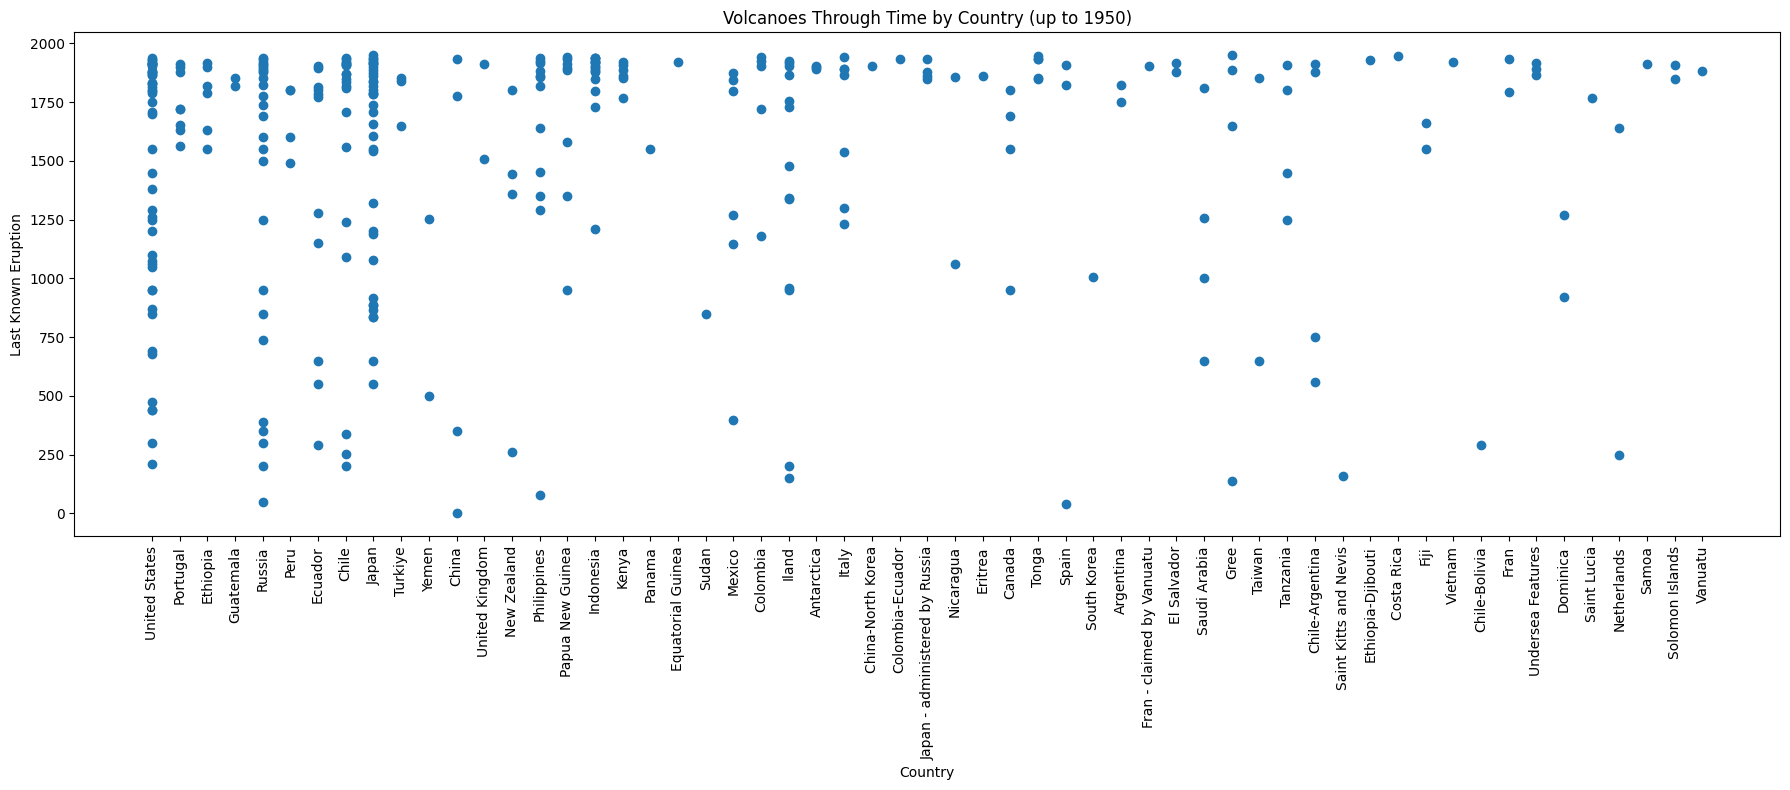

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_excel("VCLocsV2.xlsx")

# Filter for eruptions until 1950
df_filtered = df[df["Last Known Eruption"] <= 1950]

plt.figure(figsize=(18, 8))

# Create scatter plot
scatter = plt.scatter(
    df_filtered["Country"],
    df_filtered["Last Known Eruption"],
)

plt.xlabel("Country")
plt.ylabel("Last Known Eruption")
plt.title("Volcanoes Through Time by Country (up to 1950)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

####**Figure 2**: Erruptions Per Country in 500-year increments, 0AD to 2000AD (Pie Chart)

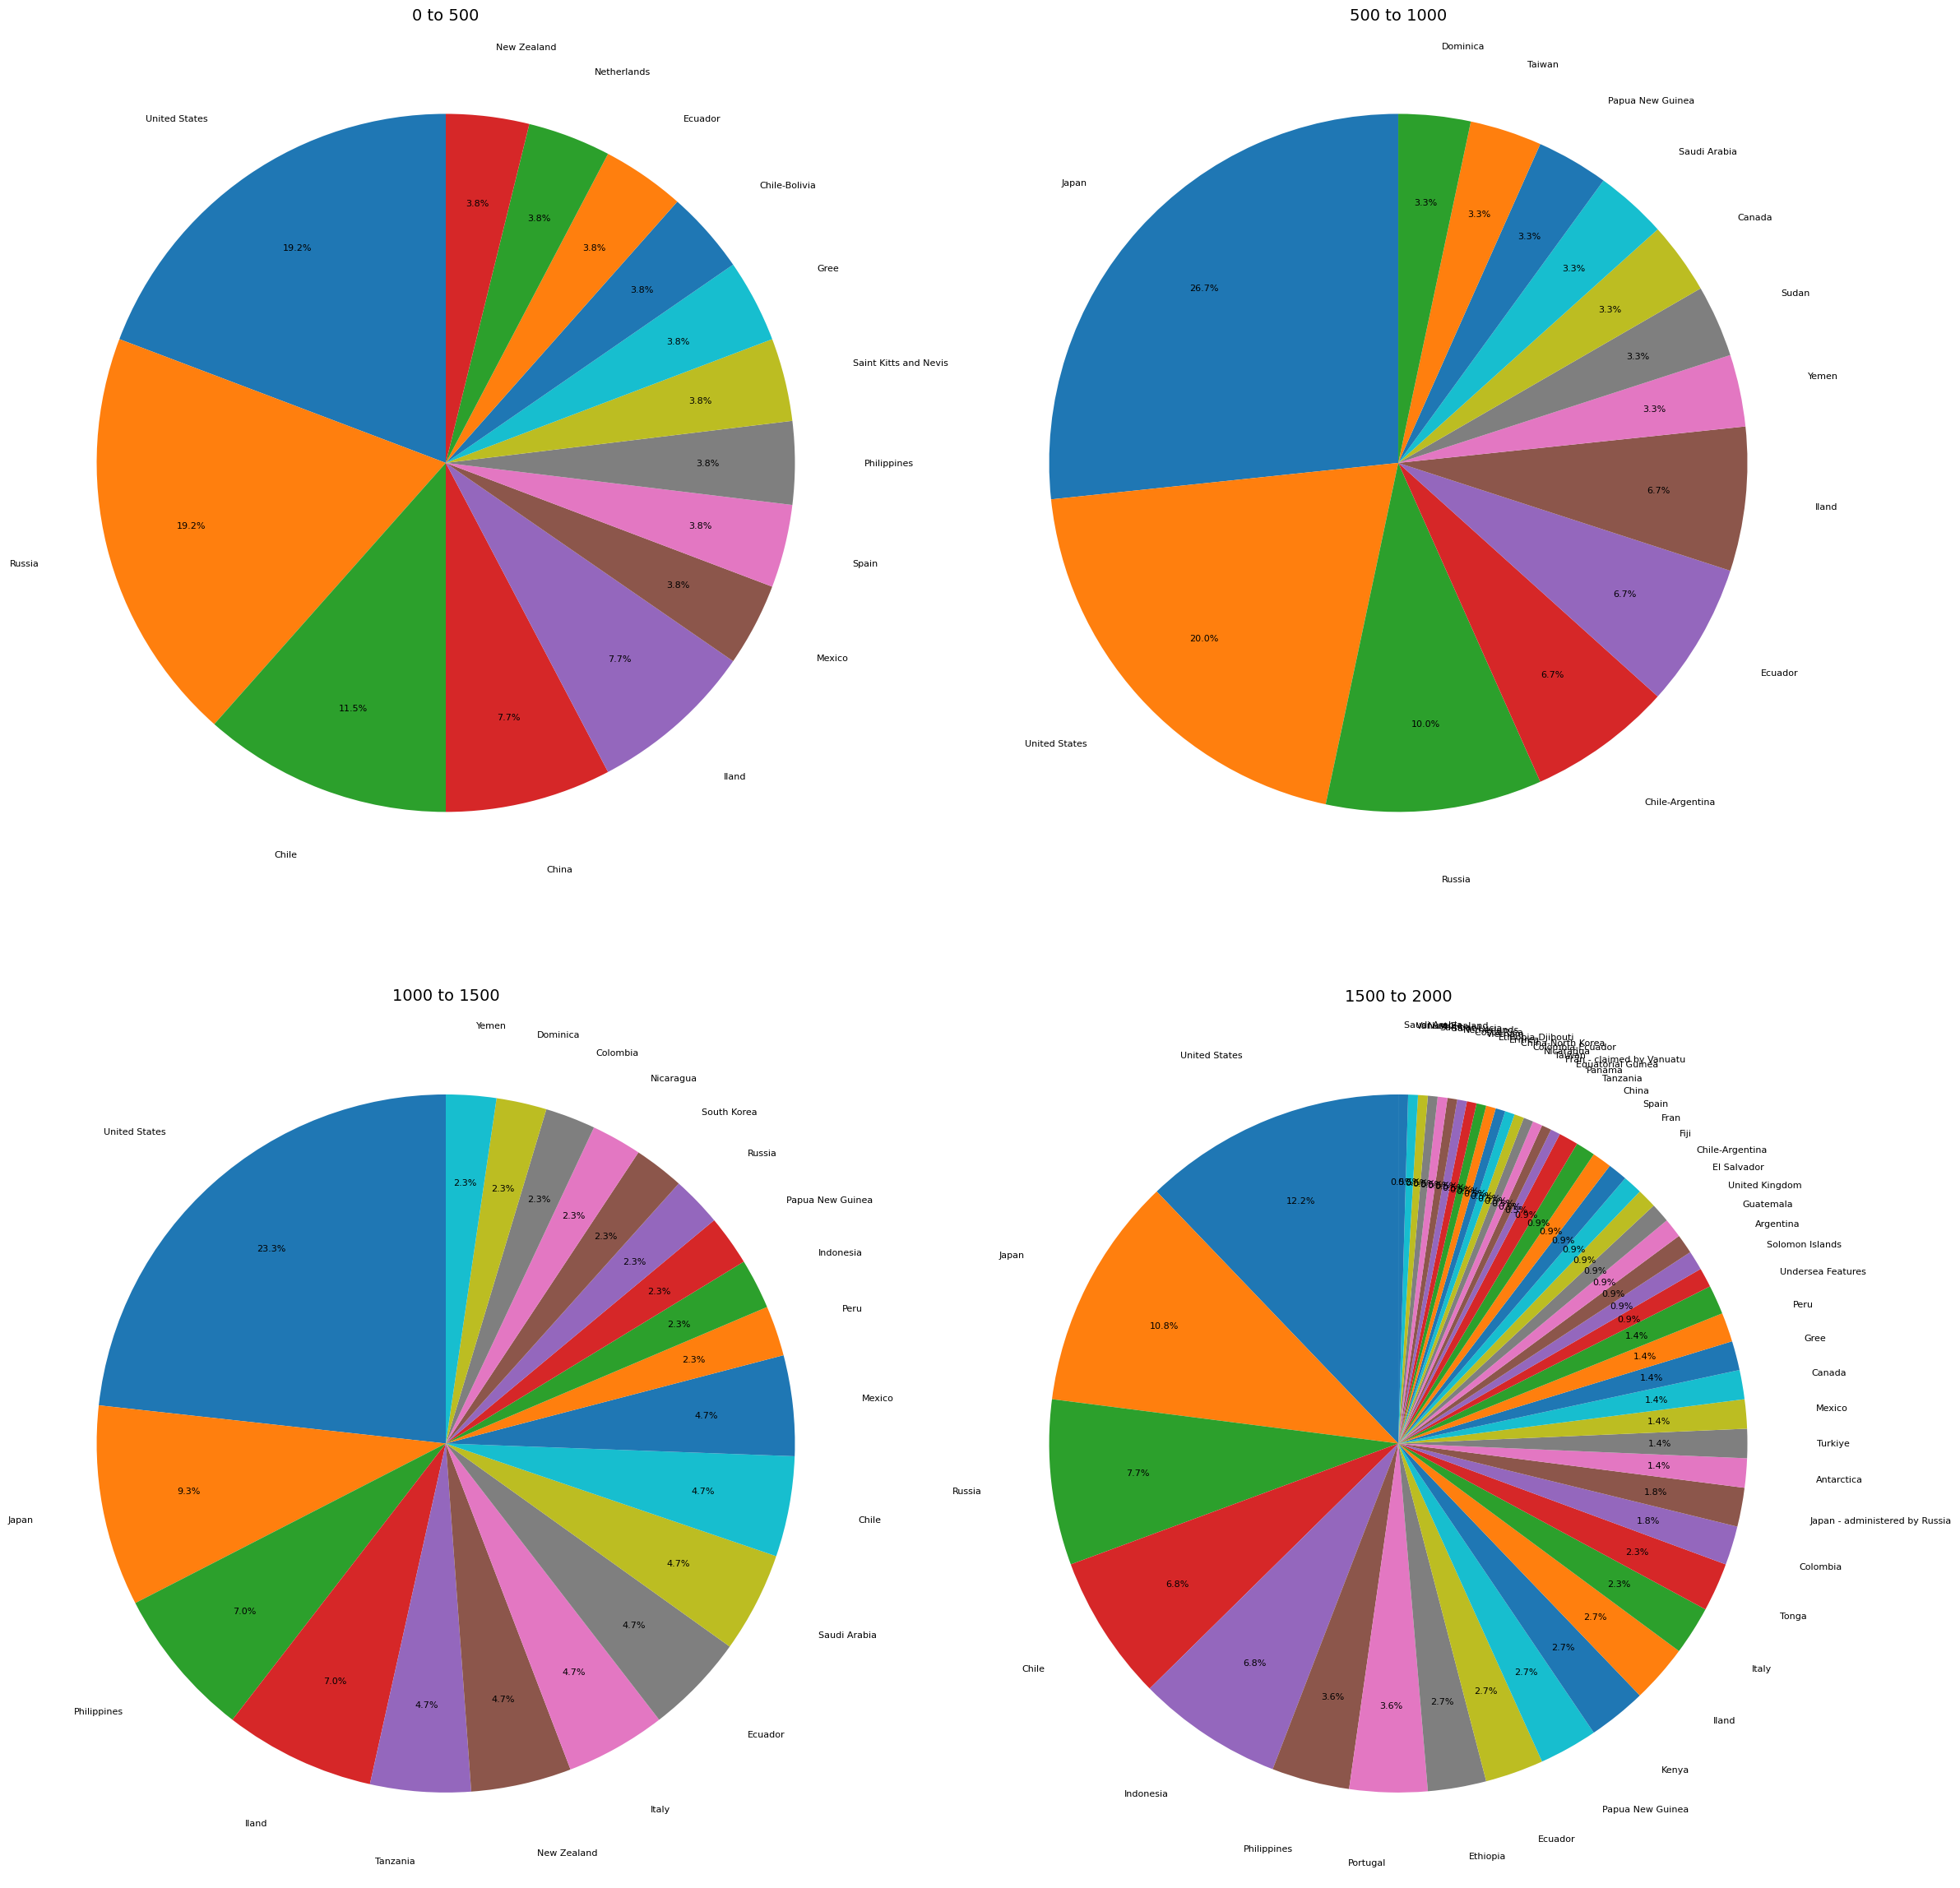

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# Load the data
df = pd.read_excel("VCLocsV2.xlsx")

# Remove missing values
df = df.dropna(subset=["Last Known Eruption", "Country"])

# Keep eruptions up to 1950
df_filtered = df[df["Last Known Eruption"] <= 1950]

# Create 500-year bins
start_year = int(df_filtered["Last Known Eruption"].min() // 500 * 500)
end_year = 2000

bins = list(range(start_year, end_year + 500, 500))
n_bins = len(bins) - 1

# Create subplot grid
cols = 2
rows = math.ceil(n_bins / cols)

fig, axes = plt.subplots(rows, cols, figsize=(24, 12 * rows))
axes = axes.flatten()

# Store wedge information
wedge_data = []

# Create pie charts
for i in range(n_bins):

    start = bins[i]
    end = bins[i + 1]

    subset = df_filtered[
        (df_filtered["Last Known Eruption"] >= start) &
        (df_filtered["Last Known Eruption"] < end)
    ]

    country_counts = subset["Country"].value_counts()

    ax = axes[i]

    if len(country_counts) > 0:

        wedges, texts, autotexts = ax.pie(
            country_counts.values,
            labels=country_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            labeldistance=1.2,
            pctdistance=0.75,
            textprops={'fontsize': 8}
        )

        ax.set_title(f"{start} to {end}", fontsize=14)

        # Store metadata for hovering
        for wedge, country in zip(wedges, country_counts.index):

            eruption_years = subset[
                subset["Country"] == country
            ]["Last Known Eruption"].tolist()

            wedge_data.append({
                "wedge": wedge,
                "country": country,
                "years": eruption_years
            })

    else:
        ax.set_title(f"{start} to {end}\nNo Data")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Create annotation box
annot = axes[0].annotate(
    "",
    xy=(0, 0),
    xytext=(20, 20),
    textcoords="offset points",
    bbox=dict(boxstyle="round", fc="white", alpha=0.8),
    arrowprops=dict(arrowstyle="->")
)

annot.set_visible(False)


plt.tight_layout()
plt.show()

####**Figure 3**: Number of Erruptions per Country 1500AD to 2000AD (Bar Graph)

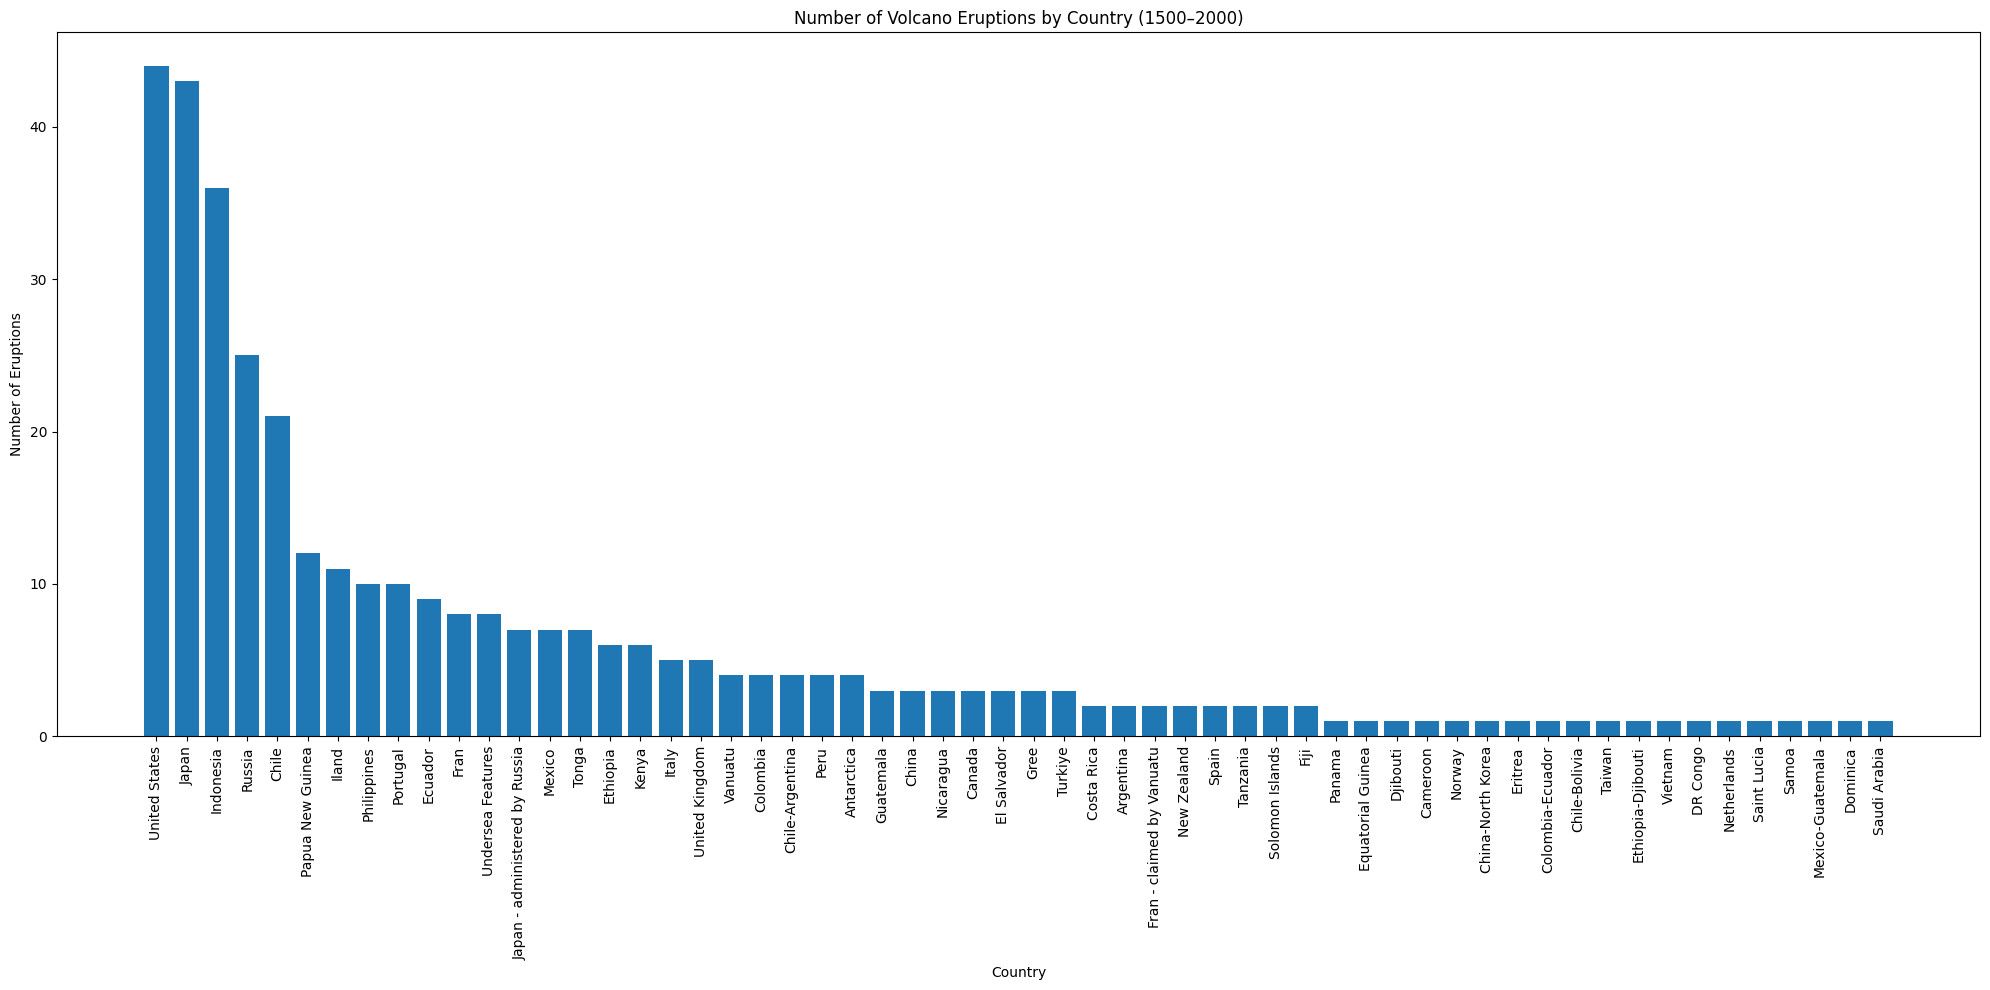

In [ ]:
# -----------------------------
# BAR GRAPH: Number of Eruptions by Country (1500–2000)
# -----------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("VCLocsV2.xlsx")

# Remove missing values
df = df.dropna(subset=["Last Known Eruption", "Country"])

# Filter years
df_recent = df[
    (df["Last Known Eruption"] >= 1500) &
    (df["Last Known Eruption"] <= 2000)
]

# Count eruptions by country
country_counts = (
    df_recent["Country"]
    .value_counts()
    .sort_values(ascending=False)
)

# Create bar graph
plt.figure(figsize=(20, 10))

plt.bar(
    country_counts.index,
    country_counts.values
)

plt.xlabel("Country")
plt.ylabel("Number of Eruptions")
plt.title("Number of Volcano Eruptions by Country (1500–2000)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

###**Analysis of Figures 1-3**: Dataset Flaws, Justifications and more

#**Erruption Coding and Analysis**

---




## **Visually Plotting Volcanic Erruptions on Earth** (8300BCE to 2026 AD)

####**Figure 1**: Volcanic Erruptions Across the Globe 8300BCE to 2026 AD
**Why?**

Getting a visual plot of global volcanic erruptions helps to visualise where erruptions are occuring and to observe the spatial clustering.

In [ ]:
# Import packages
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# Read Headings to check columns have the right name. With the amount of changes I made to my dataset throughout this process, this was the easiest way to make sure my code is running the right dataset
df = pd.read_excel("VCLocsV2.xlsx")
print(df.head(0))

Empty DataFrame
Columns: [Volcano Name, Country, Volcano Landform, Primary Volcano Type, Last Known Eruption, Latitude, Longitude, Elevation (m), Dominant Rock Type, Unnamed: 9, Unnamed: 10, Unnamed: 11]
Index: []


In [ ]:
# Loading data
df = pd.read_excel(
    "VCLocsV2.xlsx",
    header=None)

# Use first row as headers
df.columns = df.iloc[0]

# Remove header row from data
df = df[1:]

# Clean column names
df.columns = df.columns.str.strip()

# Keeping Columns I want to be included in the graph

df = df[[
    "Primary Volcano Type",
    "Latitude",
    "Longitude",
    "Volcano Landform",
    "Elevation (m)",
    "Dominant Rock Type",
    "Last Known Eruption"
]]

# CLEAN DATA

# Convert coordinates to numeric
df["Latitude"] = pd.to_numeric(
    df["Latitude"],
    errors="coerce"
)

df["Longitude"] = pd.to_numeric(
    df["Longitude"],
    errors="coerce"
)

# Convert elevation
df["Elevation (m)"] = pd.to_numeric(
    df["Elevation (m)"],
    errors="coerce"
)

# Remove invalid coordinates
df = df.dropna(subset=["Latitude", "Longitude"])

# Creating a colour map

volcano_types = df["Primary Volcano Type"].unique()

volcano_colours = {
    v: px.colors.qualitative.Dark24[i % 24]
    for i, v in enumerate(volcano_types)
}

# Creating the Figure

fig = go.Figure()

# Adding Volcaoes to map
for vtype in volcano_types:

    subset = df[df["Primary Volcano Type"] == vtype]

    fig.add_trace(
        go.Scattergeo(

            lon=subset["Longitude"],
            lat=subset["Latitude"],

            mode="markers",

            marker=dict(
                size=8,
                color=volcano_colours[vtype],
                opacity=0.8
            ),

            # Adding HOVER INFORMATION

            text=[
                f"""
                <b>Primary Volcano Type:</b> {vt}<br>
                <b>Volcano Landform:</b> {landform}<br>
                <b>Last Known Eruption:</b> {eruption}<br>
                <b>Latitude:</b> {lat}<br>
                <b>Longitude:</b> {lon}<br>
                <b>Elevation (m):</b> {elev}<br>
                <b>Dominant Rock Type:</b> {rock}
                """
                for vt, landform, eruption, lat, lon, elev, rock in zip(
                    subset["Primary Volcano Type"],
                    subset["Volcano Landform"],
                    subset["Last Known Eruption"],
                    subset["Latitude"],
                    subset["Longitude"],
                    subset["Elevation (m)"],
                    subset["Dominant Rock Type"]
                )
            ],

            hoverinfo="text",

            name=vtype
        )
    )

# Formating layout and visuals

fig.update_layout(

    title="Global Volcano Erruptions, 8300BCE - 2026 AD (Figure 1)",

    height=850,

    geo=dict(

        projection_type="equirectangular",

        showland=True,
        landcolor="rgb(220,220,220)",

        showocean=True,
        oceancolor="rgb(180,210,255)",

        showcountries=True,
        countrycolor="gray",

        showcoastlines=True,
        coastlinecolor="black",

        showframe=False
    ),

    legend=dict(
        title="Primary Volcano Type"
    )
)

# Display MAP

fig.show()

####**Figure 1.1**: Volcanic Erruptions Across the Globe 0-2026AD, 100 year clusters
**Why?**

Further trying to visualise time and spatial correlation between volcanic erruptions.

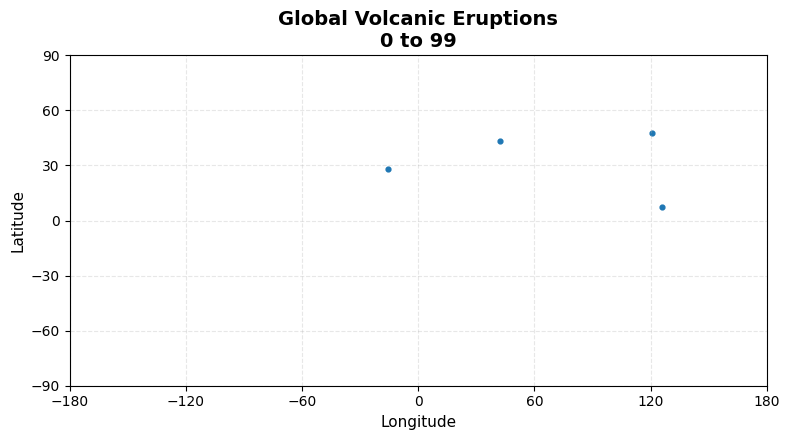

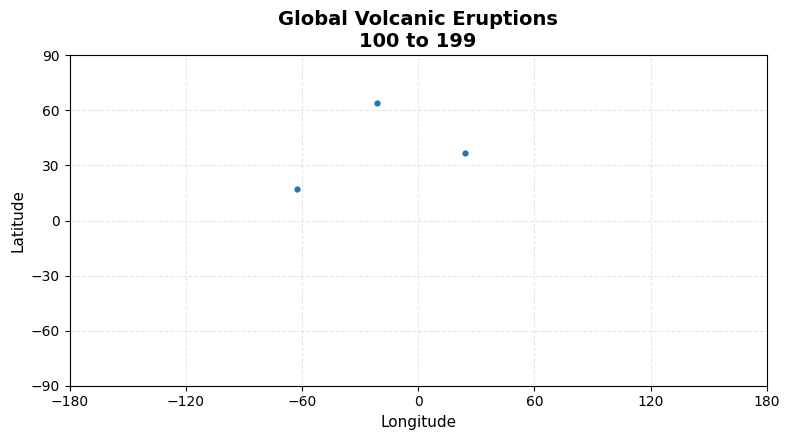

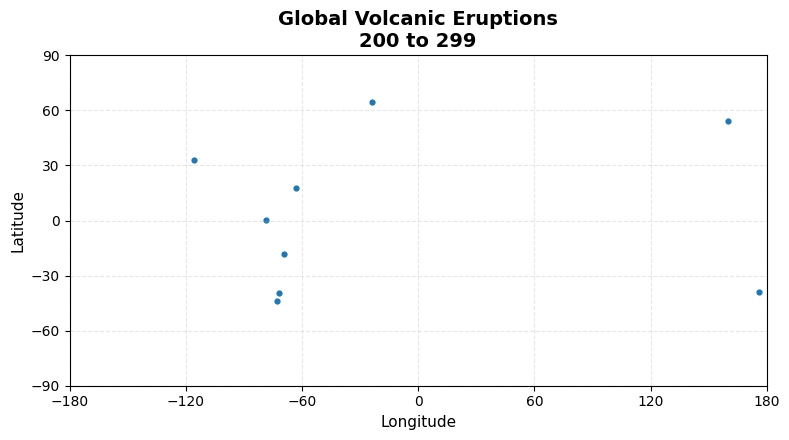

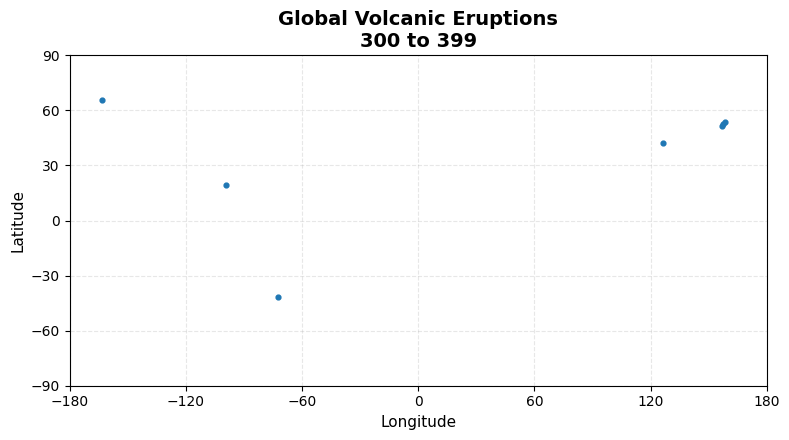

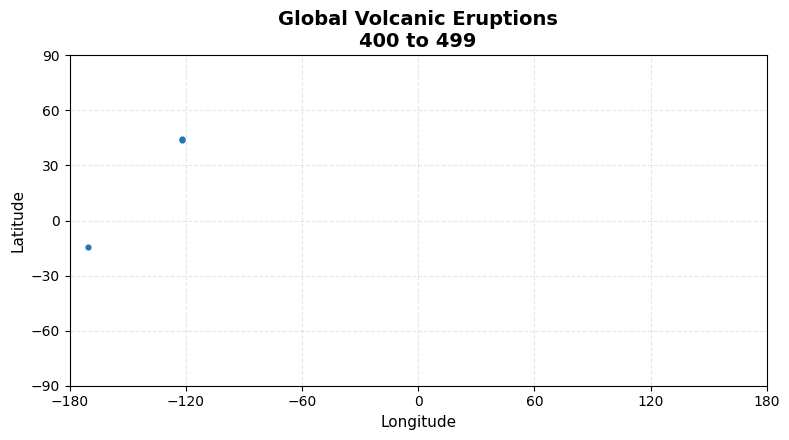

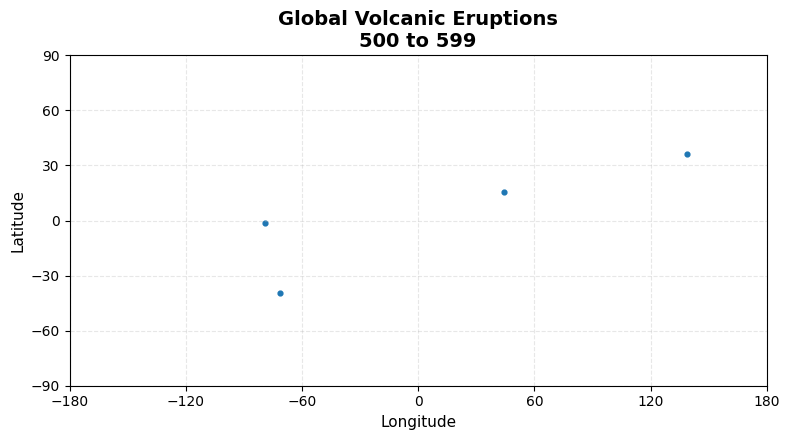

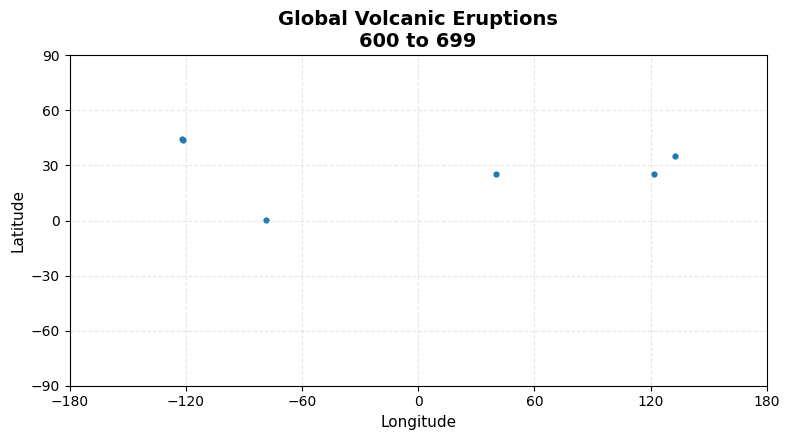

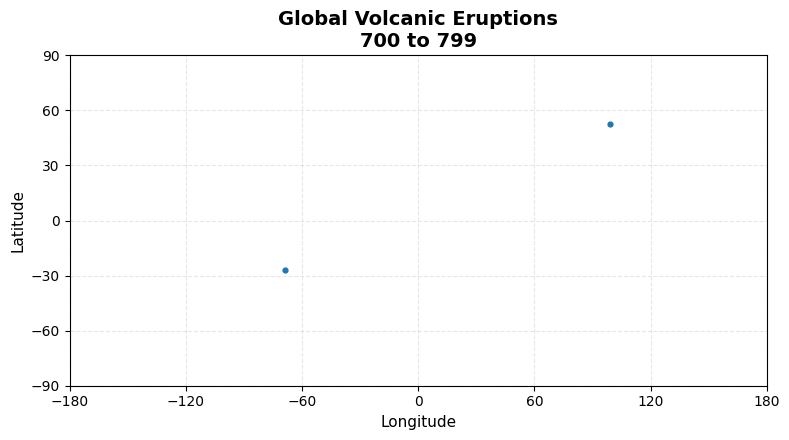

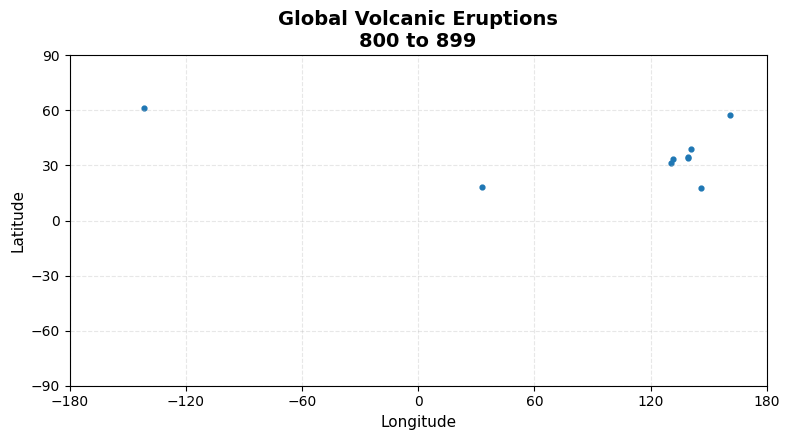

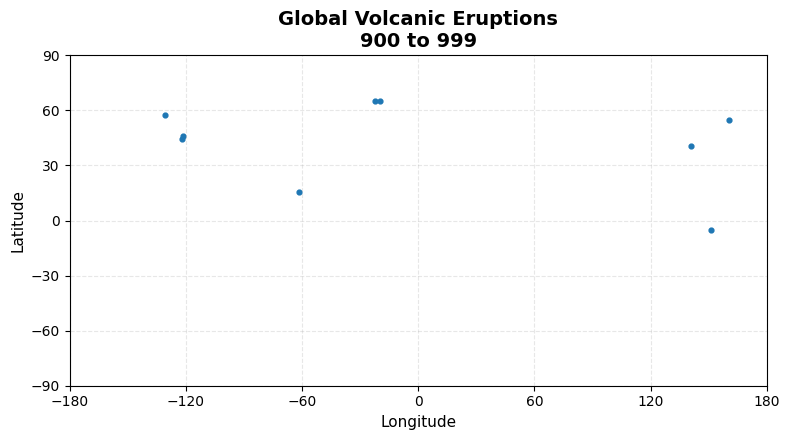

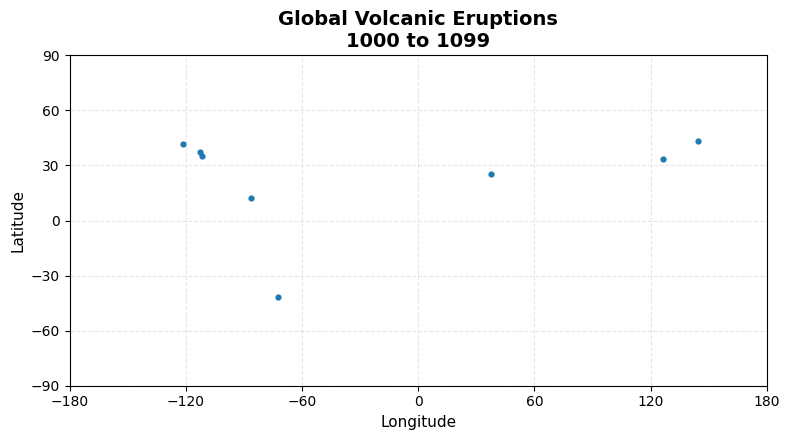

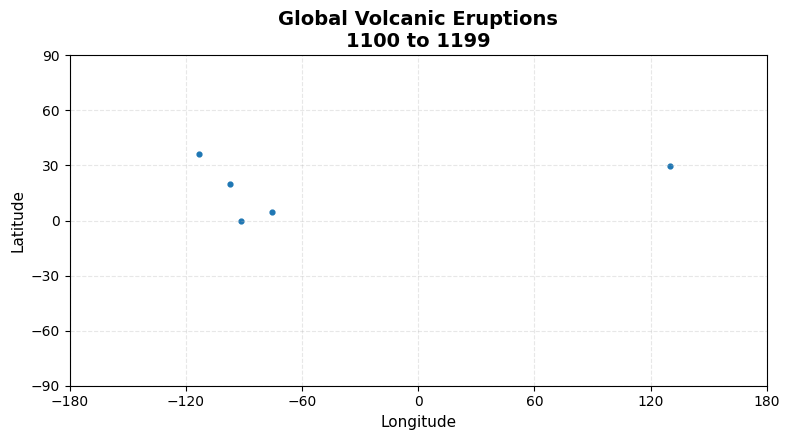

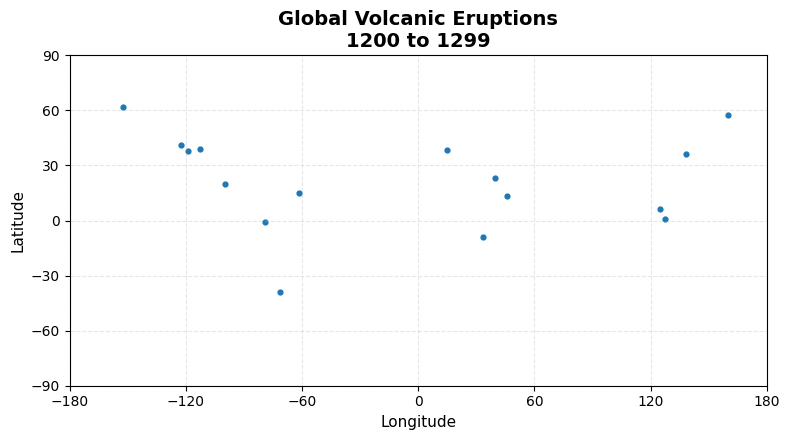

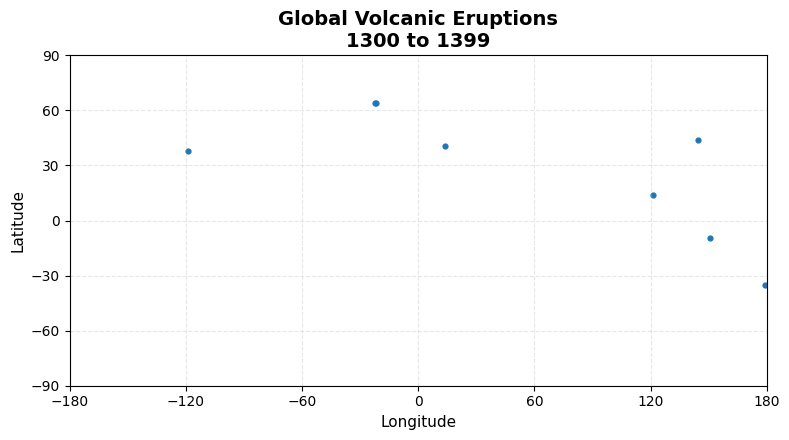

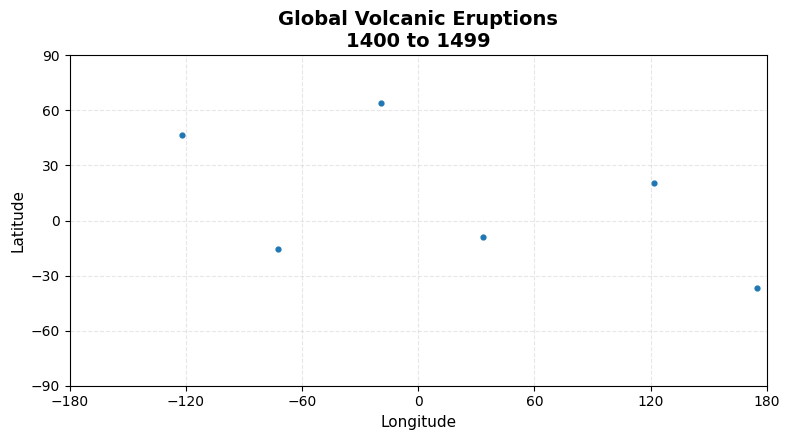

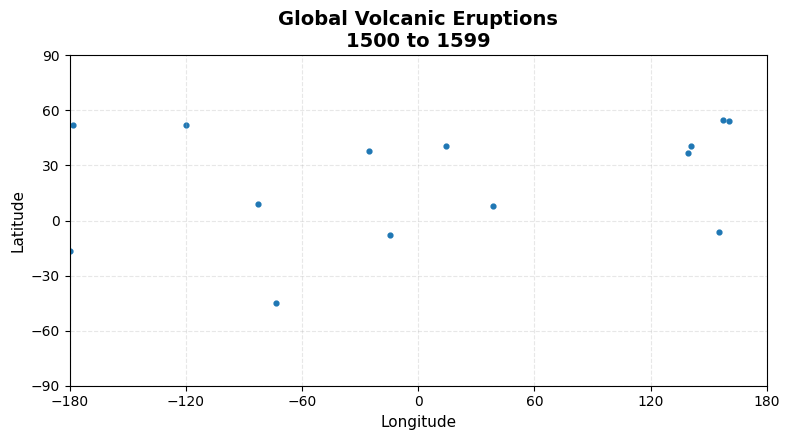

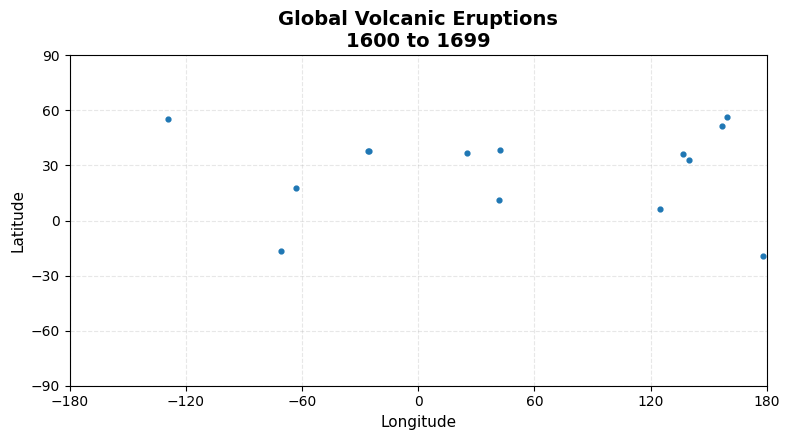

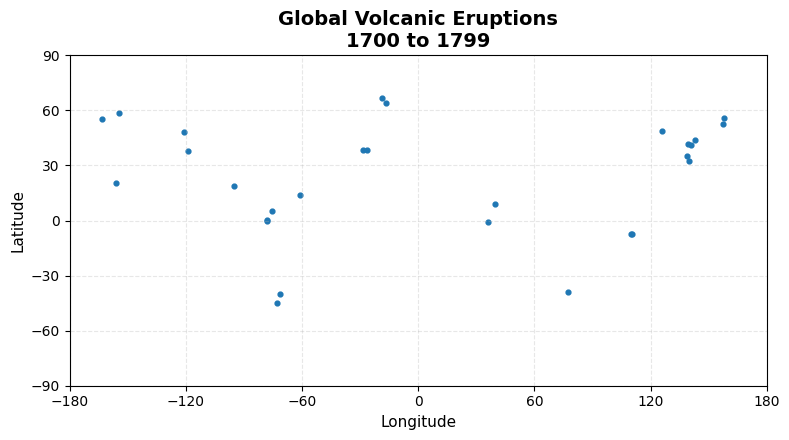

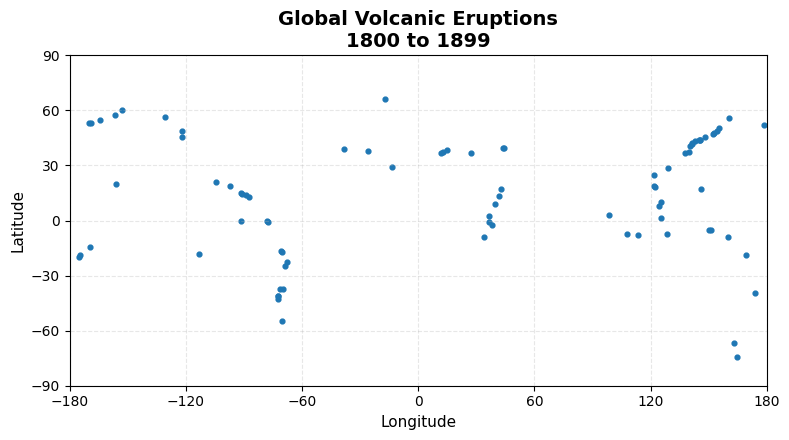

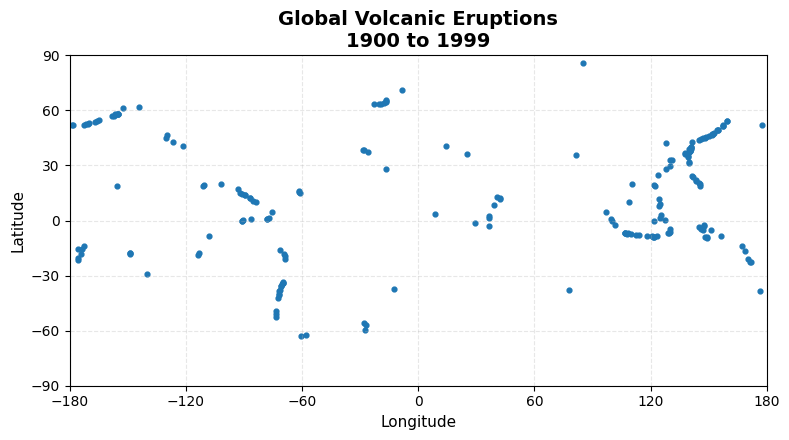

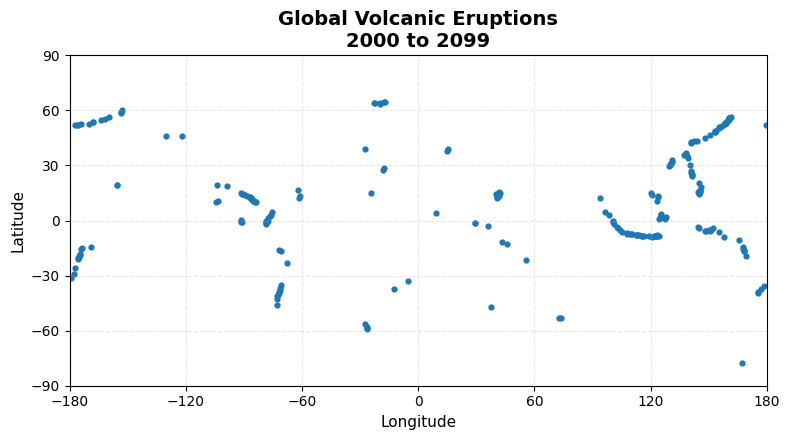

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Loading Datsets to be used

df = pd.read_excel( "VCLocsV2.xlsx", header=None)

# Use first row as headers
df.columns = df.iloc[0]

# Remove header row
df = df[1:]

# Clean column names
df.columns = df.columns.str.strip()

# Keep required columns
df = df[["Latitude","Longitude","Last Known Eruption"]]

# Create numeric year column
df["Year"] = df["Last Known Eruption"].apply(convert_year)

# Remove missing years
df = df.dropna(subset=["Year"])

# Convert to integer
df["Year"] = df["Year"].astype(int)

# Creating Groups

df["Year Group"] = ((df["Year"] // 100) * 100)

# Unique groups
groups = sorted(df["Year Group"].unique())

# Creating seperate maps
for group in groups:

    subset = df[df["Year Group"] == group ]

    # Create smaller figure
    plt.figure(figsize=(8, 4.5))

    # Plot eruptions
    plt.scatter(subset["Longitude"],subset["Latitude"], s=12)

    # Titles and headings
    plt.title( f"Global Volcanic Eruptions\n{group} to {group + 99}",fontsize=14, fontweight="bold")

    # Axis labels
    plt.xlabel( "Longitude",fontsize=11)

    plt.ylabel(  "Latitude",fontsize=11)

    # Axis limits
    plt.xlim(-180, 180)
    plt.ylim(-90, 90)

    # Tick formatting
    plt.xticks([-180, -120, -60, 0, 60, 120, 180])

    plt.yticks([-90, -60, -30, 0, 30, 60, 90])

    # Grid
    plt.grid( alpha=0.3,linestyle="--")

    # Improve spacing
    plt.tight_layout()

    # Show graph
    plt.show()



---


## **Linearly Plotting Volcanic Erruptions Overtime**: Analysing Correlation


####**Figure 2**: Volcanic Erruptions Per-year 0BCE to 2026 AD
**Why?**

As my first linear plot, I wanted to just have a look at what the data gave me so I can try and visually identify any issues or outliers in the dataset. This helped me to identify that the large spike in volcanic erruptions towards the start of the 20th century was simply due to technological advancements that made identifying erruptions easier.

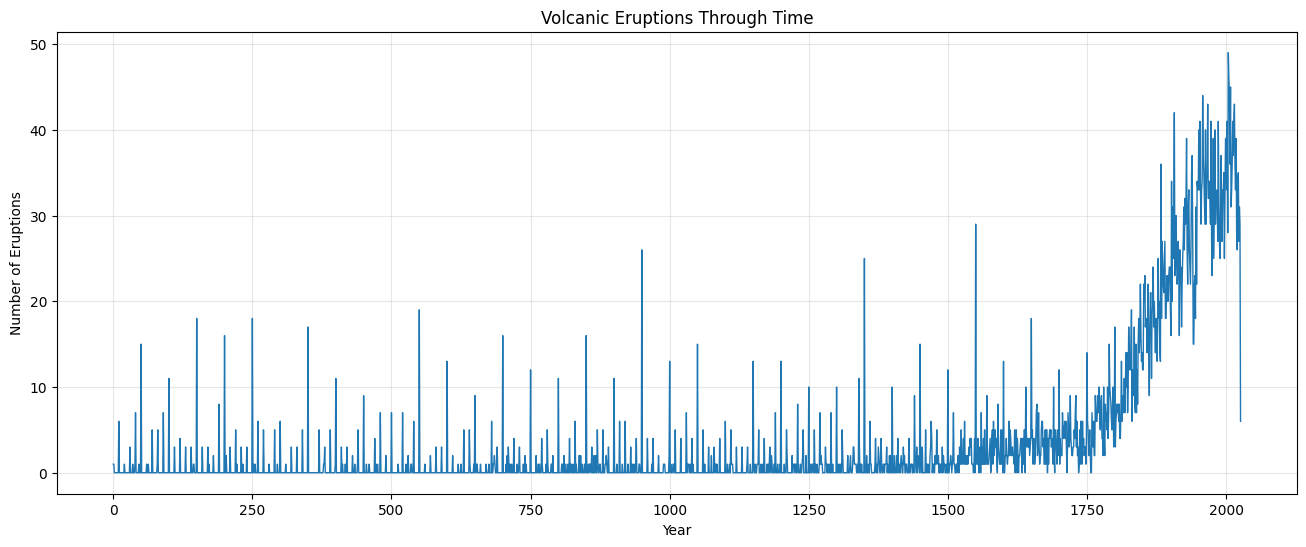

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("VCErruptionsV2.xlsx")

# Create cleaned Year column
df["Year"] = df["Start Year"].apply(convert_year)

# Remove rows with missing years
df_clean = df.dropna(subset=["Year"])

# Convert Year column to integers
df_clean["Year"] = df_clean["Year"].astype(int)

# Count eruptions per year
year_counts = (df_clean["Year"].value_counts() .sort_index())

# Create full time series
years = range( df_clean["Year"].min(), df_clean["Year"].max() + 1)

counts = [year_counts.get(year, 0) for year in years]

# Plot graph
plt.figure(figsize=(16, 6))

plt.plot(years,counts,linewidth=1)

plt.title("Volcanic Eruptions Through Time")

plt.xlabel("Year")

plt.ylabel("Number of Eruptions")

plt.grid(alpha=0.3)

plt.show()

####**Figure 3**: Volcanic Erruptions Per-Year 1950-2026

**Why?**

After figure 2, I wanted to try and cut the timescale down to focus on erruptions after the increase in monitoring techniques following the space race. This way, the dataset cannot be impacted by a lack of monitoring.

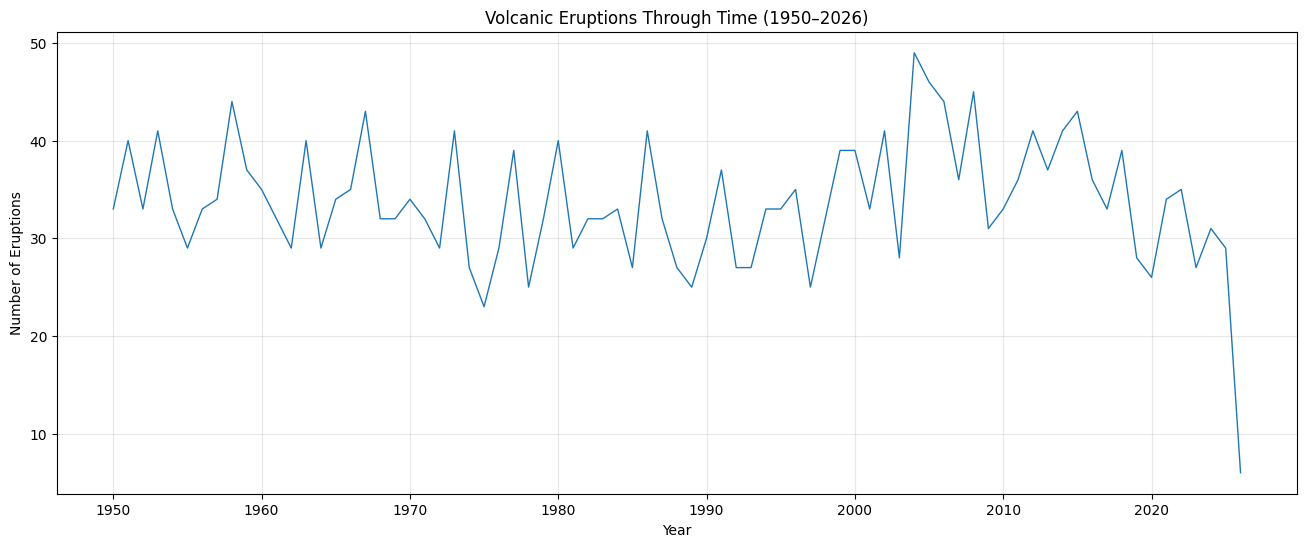

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("VCErruptionsV2.xlsx")

# Create cleaned Year column
df["Year"] = df["Start Year"].apply(convert_year)

# Remove rows with missing years
df_clean = df.dropna(subset=["Year"])

# Convert Year column to integers
df_clean["Year"] = df_clean["Year"].astype(int)

# Keep only data from 1950–2026
df_clean = df_clean[(df_clean["Year"] >= 1950) & (df_clean["Year"] <= 2026)]

# Count eruptions per year
year_counts = (df_clean["Year"].value_counts().sort_index())

# Create full time series
years = range(1950, 2027)

counts = [year_counts.get(year, 0)for year in years]

# Plot graph
plt.figure(figsize=(16, 6))

plt.plot(years,counts,linewidth=1)

plt.title("Volcanic Eruptions Through Time (1950–2026)")

plt.xlabel("Year")

plt.ylabel("Number of Eruptions")

plt.grid(alpha=0.3)

plt.show()

####**Interpreting Figures 2 and 3:** Explaining and Interpreting the Erruption Decrease in 2026

The decrease shown in 2026 is not evidence of a sudden reduction in volcanic activity. Instead, it reflects a limitation of the dataset and the timing of data collection. Because the year 2026 is still in progress and only a few months of data have been recorded, the total number of eruptions for that year is incomplete.

Volcanic eruption databases are continuously updated as new eruptions occur and are verified. As a result, annual totals for the current year are always lower than completed years until the full year has passed. This creates the appearance of a sharp decline in Figures 2 and 3, even though volcanic activity may continue at levels similar to previous years.

For this reason, 2026 should be treated as a partial dataset and excluded from long-term trend analysis. Removing 2026 would provide a more accurate representation of eruption patterns over time and prevent misleading conclusions about a decrease in global volcanic activity.


#### Ways we can prevent this from impacting our data

1.  Remove 2026 values entirely
2. Treat these entries separately by distinguishing between historical eruptions and ongoing or recently active volcanoes, rather than combining them in the same dataset.
1.   Improve accuracy by using full eruption histories instead of just the “last known eruption” field
2.   Group data into larger time intervals, such as decades, which reduces noise and smooths out reporting artefacts

####**Figures (4.1, 4.2, 4.3, 4.4 and 4.5)**: Experimenting with Different methods of cleaning data to remove 2026 issues

**Why?**
 From Figures 2 and 3, it became clear to me that the incomplete 2026 data created misleading trends within the dataset. To improve the reliability of the correlation analysis, I tested different data-cleaning methods to reduce the impact of this partial year. Experimenting with these approaches helps determine which method produces the most accurate representation of long-term volcanic eruption patterns while minimising distortions caused by incomplete or inconsistent reporting.

**Figure 4.1**

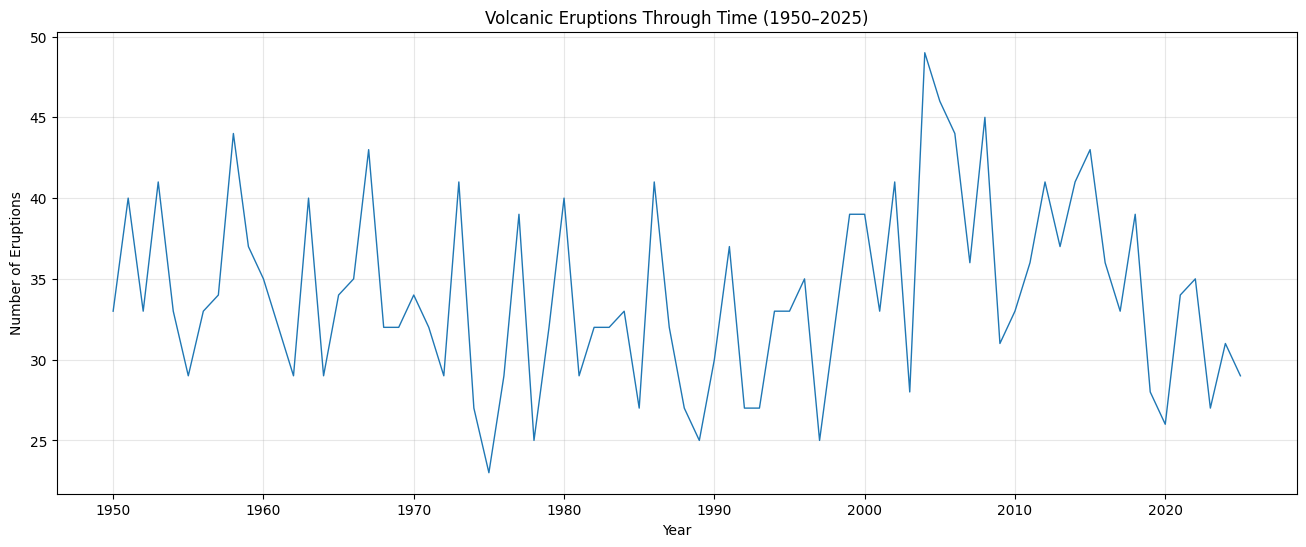

In [ ]:
#Figure 4.1 - Cutting out 2026 Data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("VCErruptionsV2.xlsx")

# Create cleaned Year column
df["Year"] = df["Start Year"].apply(convert_year)

# Remove rows with missing years
df_clean = df.dropna(subset=["Year"])

# Convert Year column to integers
df_clean["Year"] = df_clean["Year"].astype(int)

# Keep only data from 1950–2025
df_clean = df_clean[
    (df_clean["Year"] >= 1950) &
    (df_clean["Year"] <= 2025)
]

# Count eruptions per year
year_counts = (
    df_clean["Year"]
    .value_counts()
    .sort_index()
)

# Create full time series
years = range(1950, 2026)

counts = [
    year_counts.get(year, 0)
    for year in years
]

# Plot graph
plt.figure(figsize=(16, 6))

plt.plot(
    years,
    counts,
    linewidth=1
)

plt.title("Volcanic Eruptions Through Time (1950–2025)")

plt.xlabel("Year")

plt.ylabel("Number of Eruptions")

plt.grid(alpha=0.3)

plt.show()

**Figure 4.2: Decadal Binning**

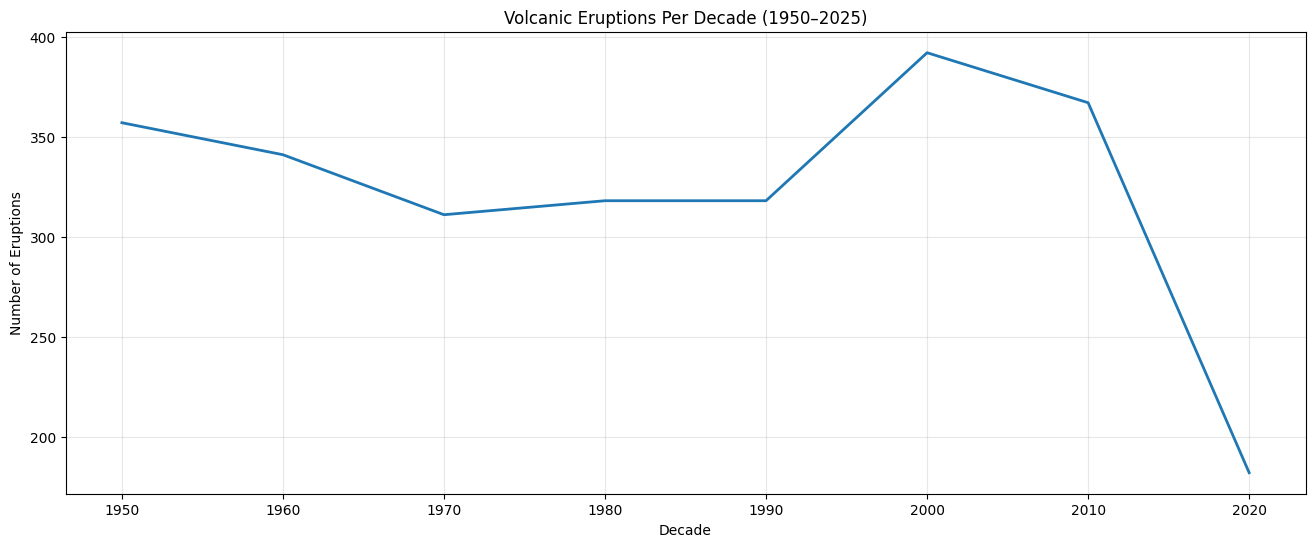

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("VCErruptionsV2.xlsx")

# Create cleaned Year column
df["Year"] = df["Start Year"].apply(convert_year)

# Remove rows with missing years
df_clean = df.dropna(subset=["Year"])

# Convert Year column to integers
df_clean["Year"] = df_clean["Year"].astype(int)

# Keep only data from 1950–2025
df_clean = df_clean[
    (df_clean["Year"] >= 1950) &
    (df_clean["Year"] <= 2025)
]

# Create decade bins
df_clean["Decade"] = (
    df_clean["Year"] // 10
) * 10

# Count eruptions per decade
decade_counts = (
    df_clean["Decade"]
    .value_counts()
    .sort_index()
)

# Plot graph
plt.figure(figsize=(16, 6))

plt.plot(
    decade_counts.index,
    decade_counts.values,
    linewidth=2
)

plt.title("Volcanic Eruptions Per Decade (1950–2025)")

plt.xlabel("Decade")

plt.ylabel("Number of Eruptions")

plt.xticks(decade_counts.index)

plt.grid(alpha=0.3)

plt.show()

**Figure 4.3 - Comparison of original, Cut-Off and Decadal Binning**

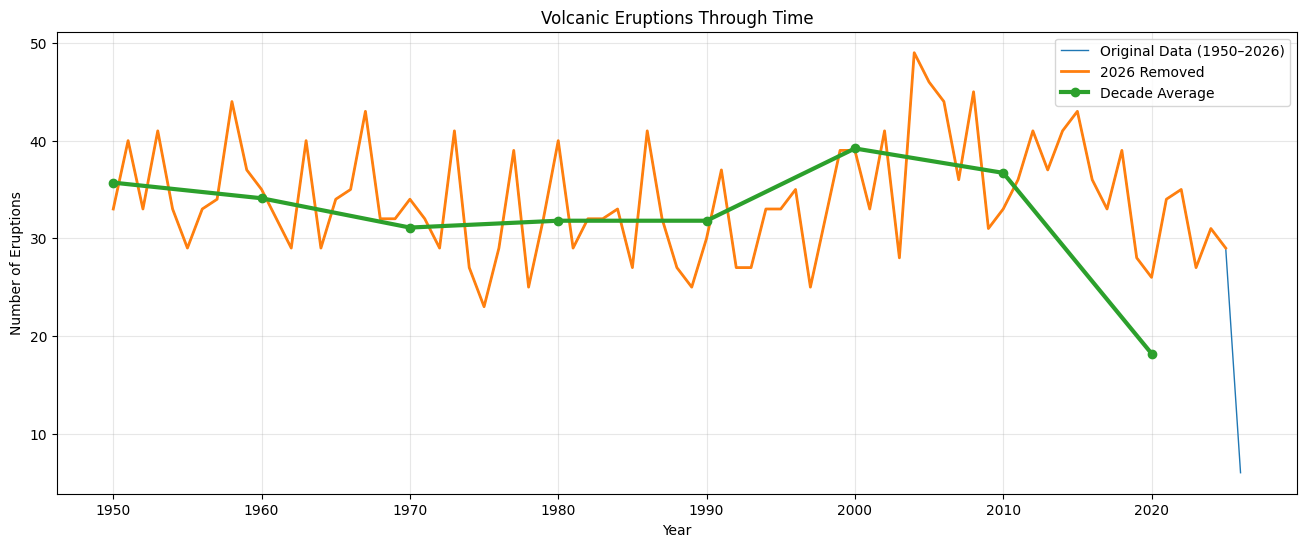

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("VCErruptionsV2.xlsx")

# Create cleaned Year column
df["Year"] = df["Start Year"].apply(convert_year)

# Remove rows with missing years
df_clean = df.dropna(subset=["Year"])

# Convert Year column to integers
df_clean["Year"] = df_clean["Year"].astype(int)

# Original Data

df_original = df_clean[
    (df_clean["Year"] >= 1950) &
    (df_clean["Year"] <= 2026)
]

# Count eruptions per year
original_counts = (
    df_original["Year"]
    .value_counts()
    .sort_index()
)

years_original = range(1950, 2027)

counts_original = [
    original_counts.get(year, 0)
    for year in years_original
]

# Cutting Data

df_cutoff = df_clean[
    (df_clean["Year"] >= 1950) &
    (df_clean["Year"] <= 2025)
]

# Count eruptions per year
cutoff_counts = (
    df_cutoff["Year"]
    .value_counts()
    .sort_index()
)

years_cutoff = range(1950, 2026)

counts_cutoff = [
    cutoff_counts.get(year, 0)
    for year in years_cutoff
]

# Decadal Binning

df_binned = df_cutoff.copy()

df_binned["Decade"] = (
    df_binned["Year"] // 10
) * 10

# Average yearly eruptions within each decade
decade_counts = (
    df_binned.groupby("Decade")
    .size() / 10
)

# Adding it all together

plt.figure(figsize=(16, 6))

# Original yearly data
plt.plot(
    years_original,
    counts_original,
    linewidth=1,
    label="Original Data (1950–2026)"
)

# Cut-off yearly data
plt.plot(
    years_cutoff,
    counts_cutoff,
    linewidth=2,
    label="2026 Removed"
)

# Decade-binned average
plt.plot(
    decade_counts.index,
    decade_counts.values,
    linewidth=3,
    marker="o",
    label="Decade Average"
)

plt.title("Volcanic Eruptions Through Time")

plt.xlabel("Year")

plt.ylabel("Number of Eruptions")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

####**Interpreting Figures (4.1, 4.2 and 4.3)**
Figures 4.1, 4.2 and 4.3 demonstrate different methods of reducing variability within the volcanic eruption dataset to better identify long-term trends. Figure 4.1 removes incomplete 2026 data, improving reliability but still showing large year-to-year fluctuations that obscure broader patterns. Figure 4.2 uses decade binning to smooth short-term variability, making the overall increase in recorded eruptions since 1950 more visible, although some temporal detail is lost. Figure 4.3 is the most effective because it combines the original yearly data, the corrected cut-off data, and the decade-average trend on a single graph, allowing direct comparison between raw variability and smoothed long-term behaviour.

####**Figure 5.1**: Plotting Regression of Volcanic Erruptions Per Year (1950-2026)

**Why?**

**Time Series Analysis (Week 10)**
Time series analysis was used to study how volcanic eruptions change through time. Eruptions were counted by year and plotted on line graphs to identify patterns in eruption frequency. Moving averages and rolling means were used to smooth the data and highlight periods of high or low activity. The results will then be analysed to determine whether eruptions occur randomly or  in temporal clusters.

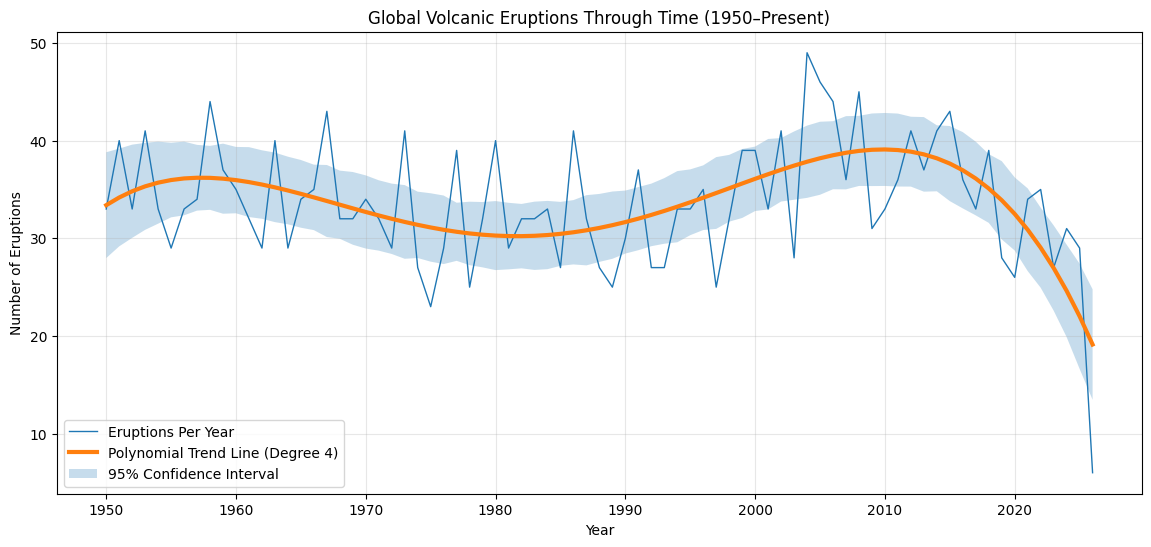

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# Load dataset
df = pd.read_excel("VCErrupt1950.xlsx")

# Convert mixed year formats into integers
def convert_year(value):
    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # Convert BCE to negative years
    if "BCE" in value:
        num = re.findall(r"\d+", value)
        return -int(num[0]) if num else None

    # Convert CE to positive years
    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    # Handle plain numeric years
    if value.isdigit():
        return int(value)

    return None

# Apply conversion
df["Year"] = df["Start Year"].apply(convert_year)

# Remove missing values
df_clean = df.dropna(subset=["Year"])
df_clean["Year"] = df_clean["Year"].astype(int)

# Filter for modern period (1950 onwards)
df_clean = df_clean[df_clean["Year"] >= 1950]

# Count eruptions per year
eruption_counts = df_clean["Year"].value_counts().sort_index()

# Create continuous yearly range
all_years = np.arange(1950, df_clean["Year"].max() + 1)

# Fill missing years with zero counts
all_counts = np.array([
    eruption_counts.get(year, 0)
    for year in all_years
])

# Build time series dataframe
time_series = pd.DataFrame({
    "Year": all_years,
    "Eruptions": all_counts
})

# Polynomial degree for trend line
degree = 4

# Fit polynomial + covariance matrix
z, cov = np.polyfit(
    time_series["Year"],
    time_series["Eruptions"],
    degree,
    cov=True
)

# Create polynomial function
p = np.poly1d(z)

# Compute trend values
trendline = p(time_series["Year"])

# Design matrix for uncertainty propagation
x = time_series["Year"].values
X = np.vander(x, degree + 1)

# Standard error of prediction
trend_std = np.sqrt(np.sum(X @ cov * X, axis=1))

# Convert to 95% confidence interval (HDO ≈ normal approximation)
z_score = 1.96
trend_upper = trendline + z_score * trend_std
trend_lower = trendline - z_score * trend_std

# Plot
plt.figure(figsize=(14,6))

# Raw data
plt.plot(
    time_series["Year"],
    time_series["Eruptions"],
    linewidth=1,
    label="Eruptions Per Year"
)

# Trend line
plt.plot(
    time_series["Year"],
    trendline,
    linewidth=3,
    label=f"Polynomial Trend Line (Degree {degree})"
)

# 95% confidence band
plt.fill_between(
    time_series["Year"],
    trend_lower,
    trend_upper,
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.xlabel("Year")
plt.ylabel("Number of Eruptions")
plt.title("Global Volcanic Eruptions Through Time (1950–Present)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

####**Figure 5.1.2: Rolling Mean Overtime**

**Why?**

Allows us to determine whether there is a meaningful relationship between time and volcanic eruption frequency, helping distinguish real long-term trends from random fluctuations. By analysing correlation over time, I can test whether eruptions are increasing, decreasing, or remaining stable rather than relying on visual patterns alone, which can be misleading due to natural variability in the data.

Pearson r = -0.051
p-value = 6.621e-01


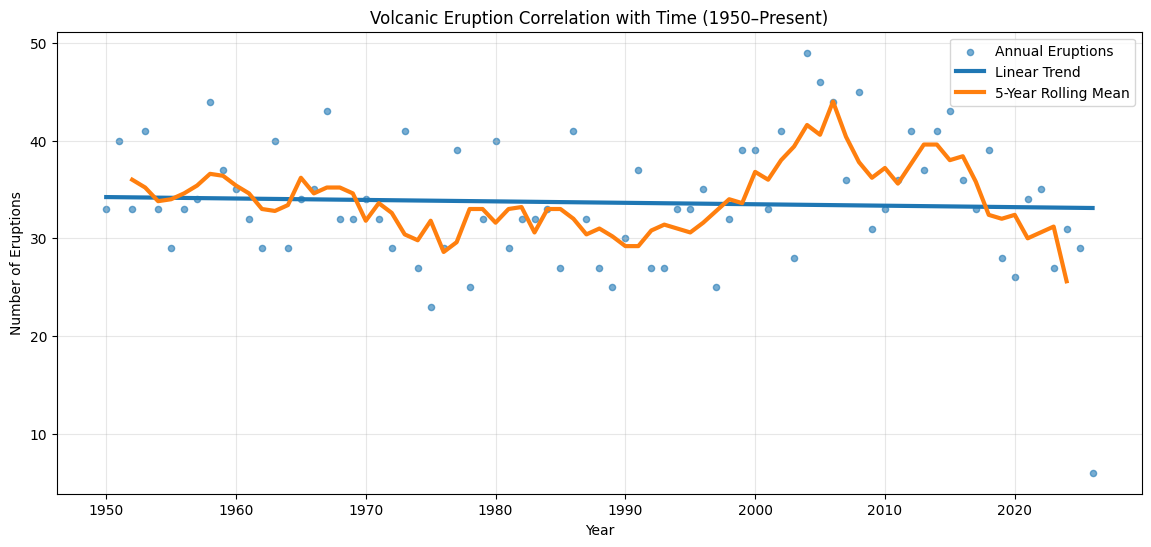

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from scipy.stats import linregress

# Load dataset
df = pd.read_excel("VCErrupt1950.xlsx")

# Convert year formats
def convert_year(value):
    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    if "BCE" in value:
        num = re.findall(r"\d+", value)
        return -int(num[0]) if num else None

    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    if value.isdigit():
        return int(value)

    return None

df["Year"] = df["Start Year"].apply(convert_year)

df_clean = df.dropna(subset=["Year"])
df_clean["Year"] = df_clean["Year"].astype(int)

df_clean = df_clean[df_clean["Year"] >= 1950]

# Count eruptions per year
eruption_counts = df_clean["Year"].value_counts().sort_index()

years = np.arange(1950, df_clean["Year"].max() + 1)

counts = np.array([eruption_counts.get(y, 0) for y in years])

# Linear regression (correlation with time)
slope, intercept, r_value, p_value, std_err = linregress(years, counts)

trend = slope * years + intercept

# Rolling mean (5-year smoothing)
rolling_mean = pd.Series(counts).rolling(window=5, center=True).mean()

# Print correlation stats
print(f"Pearson r = {r_value:.3f}")
print(f"p-value = {p_value:.3e}")

# Plot
plt.figure(figsize=(14,6))

# Raw data
plt.scatter(years, counts, s=20, alpha=0.6, label="Annual Eruptions")

# Linear trend (true correlation line)
plt.plot(years, trend, linewidth=3, label="Linear Trend")

# Smoothed signal
plt.plot(years, rolling_mean, linewidth=3, label="5-Year Rolling Mean")

plt.xlabel("Year")
plt.ylabel("Number of Eruptions")
plt.title("Volcanic Eruption Correlation with Time (1950–Present)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Figure 5.1.2: Interpretation**

The Pearson correlation analysis shows a very weak negative relationship between year and the number of volcanic eruptions **(r = -0.051)**, indicating essentially no linear association over time. The **p-value (p = 0.662)** is far above the standard significance threshold of 0.05, meaning the observed correlation is not statistically significant and is likely due to random variation in the data. Overall, this suggests that from 1950 onwards, there is no evidence of a meaningful linear increase or decrease in global volcanic eruption frequency, and the variability observed is more consistent with natural fluctuations rather than a long-term temporal trend.

####**Figure 5.2**: Plotting Regression of Volcanic Erruptions Per Year. Finding best polynomial fit (1950-2026)


In [ ]:
!pip install bambi pymc arviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 25.6 MB/s eta 0:00:00
  Attempting uninstall: pytensor
    Found existing installation: pytensor 2.38.3
    Uninstalling pytensor-2.38.3:
      Successfully uninstalled pytensor-2.38.3
  Attempting uninstall: arviz
    Found existing installation: arviz 0.22.0
    Uninstalling arviz-0.22.0:
      Successfully uninstalled arviz-0.22.0
  Attempting uninstall: pymc
    Found existing in

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning:

Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning:

Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning:

Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning:

Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: Futu


MODEL COMPARISON
           rank   elpd    p  elpd_diff  weight    se  dse  warning
4th-order     0 -240.0  6.3        0.0    0.96   5.9  0.0     True
3rd-order     1 -250.0  6.4       -8.0    0.00   8.1  4.3    False
0-order       2 -260.0  3.4      -10.0    0.04  11.0  7.0    False
1st-order     3 -260.0  4.6      -10.0    0.00  11.0  7.1    False
2nd-order     4 -260.0  5.5      -10.0    0.00  10.0  6.9    False

Best model: 4th-order


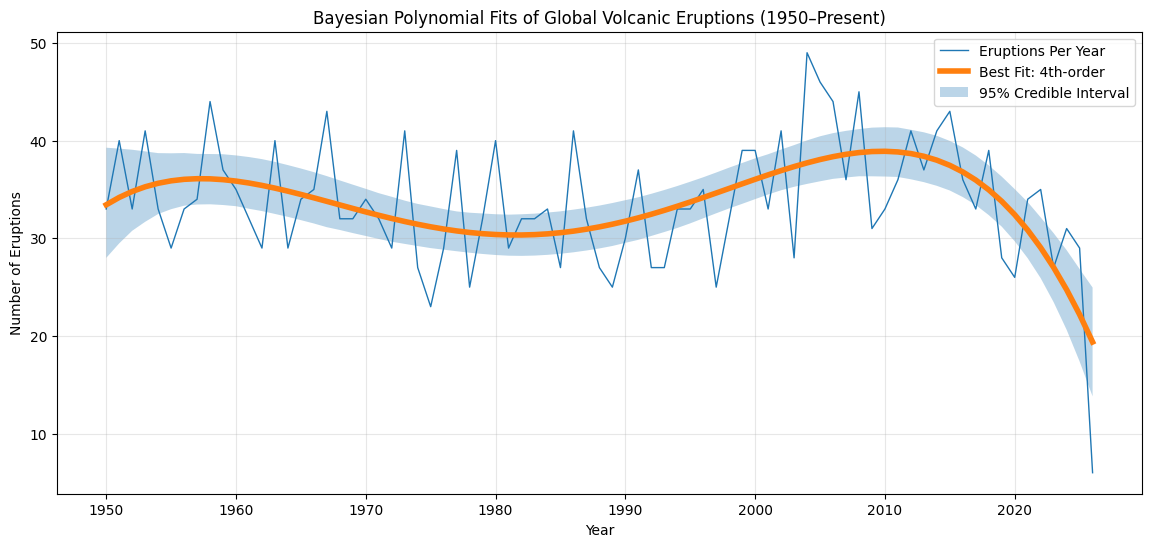

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

import bambi as bmb
import arviz as az

# Load dataset
df = pd.read_excel("VCErrupt1950.xlsx")

# Convert mixed year formats into integers
def convert_year(value):
    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    # BCE years
    if "BCE" in value:
        num = re.findall(r"\d+", value)
        return -int(num[0]) if num else None

    # CE years
    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    # Plain numeric years
    if value.isdigit():
        return int(value)

    return None

# Apply conversion
df["Year"] = df["Start Year"].apply(convert_year)

# Remove missing years
df_clean = df.dropna(subset=["Year"]).copy()
df_clean["Year"] = df_clean["Year"].astype(int)

# Filter for modern period (1950 onwards)
df_clean = df_clean[df_clean["Year"] >= 1950]

# Count eruptions per year
eruption_counts = df_clean["Year"].value_counts().sort_index()

# Create full yearly range
all_years = np.arange(1950, df_clean["Year"].max() + 1)

# Fill missing years with zeros
all_counts = np.array([
    eruption_counts.get(year, 0)
    for year in all_years
])

# Create time series dataframe
time_series = pd.DataFrame({
    "Year": all_years,
    "Eruptions": all_counts
})

# Standardise time variable for modelling stability
time_series["x"] = (
    time_series["Year"] - time_series["Year"].mean()
) / time_series["Year"].std()

# Polynomial features
time_series["x2"] = time_series["x"]**2
time_series["x3"] = time_series["x"]**3
time_series["x4"] = time_series["x"]**4

# Fit 0th-order model (no time effect)
model0 = bmb.Model("Eruptions ~ 1", time_series)
idata0 = model0.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    progressbar=False,
    idata_kwargs={"log_likelihood": True}
)

# Fit 1st-order model (linear trend)
model1 = bmb.Model("Eruptions ~ x", time_series)
idata1 = model1.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    progressbar=False,
    idata_kwargs={"log_likelihood": True}
)

# Fit 2nd-order model
model2 = bmb.Model("Eruptions ~ x + x2", time_series)
idata2 = model2.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    progressbar=False,
    idata_kwargs={"log_likelihood": True}
)

# Fit 3rd-order model
model3 = bmb.Model("Eruptions ~ x + x2 + x3", time_series)
idata3 = model3.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    progressbar=False,
    idata_kwargs={"log_likelihood": True}
)

# Fit 4th-order model
model4 = bmb.Model("Eruptions ~ x + x2 + x3 + x4", time_series)
idata4 = model4.fit(
    draws=1000,
    tune=1000,
    target_accept=0.95,
    progressbar=False,
    idata_kwargs={"log_likelihood": True}
)

# Compare models
comparison = az.compare({
    "0-order": idata0,
    "1st-order": idata1,
    "2nd-order": idata2,
    "3rd-order": idata3,
    "4th-order": idata4
})

print("\nMODEL COMPARISON")
print(comparison)

# Select best model
best_model_name = comparison.index[0]

print("\nBest model:", best_model_name)

# Assign best model
if best_model_name == "0-order":
    model_best, idata_best = model0, idata0
elif best_model_name == "1st-order":
    model_best, idata_best = model1, idata1
elif best_model_name == "2nd-order":
    model_best, idata_best = model2, idata2
elif best_model_name == "3rd-order":
    model_best, idata_best = model3, idata3
else:
    model_best, idata_best = model4, idata4

# Generate posterior predictions
predictions = model_best.predict(
    idata_best,
    kind="mean",
    inplace=False
)

posterior = predictions.posterior["mu"].values

# Mean prediction
mean_pred = posterior.mean(axis=(0, 1))

# 95% credible interval
lower = np.percentile(posterior, 2.5, axis=(0, 1))
upper = np.percentile(posterior, 97.5, axis=(0, 1))

# Plot results
plt.figure(figsize=(14, 6))

# Raw data
plt.plot(
    time_series["Year"],
    time_series["Eruptions"],
    linewidth=1,
    label="Eruptions Per Year"
)

# Best model fit
plt.plot(
    time_series["Year"],
    mean_pred,
    linewidth=4,
    label=f"Best Fit: {best_model_name}"
)

# 95% credible interval
plt.fill_between(
    time_series["Year"],
    lower,
    upper,
    alpha=0.3,
    label="95% Credible Interval"
)

plt.xlabel("Year")
plt.ylabel("Number of Eruptions")
plt.title("Bayesian Polynomial Fits of Global Volcanic Eruptions (1950–Present)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Interpeting Figure 5**

The model comparison results suggest that volcanic eruptions do show some relationship with time, but it is not a simple linear correlation. The best-performing 4th-order model indicates that the pattern in eruption frequency is non-linear and fluctuating, meaning eruptions vary in complex cycles or irregular trends rather than steadily increasing or decreasing over time. However, because simpler models also perform relatively close in ELPD, this implies that the overall time-based correlation is weak and unstable, with most variation likely driven by natural randomness rather than a strong deterministic trend.

####**Figure 6**: Plotting Regression of Volcanic Erruptions Per Year (1950-2026)


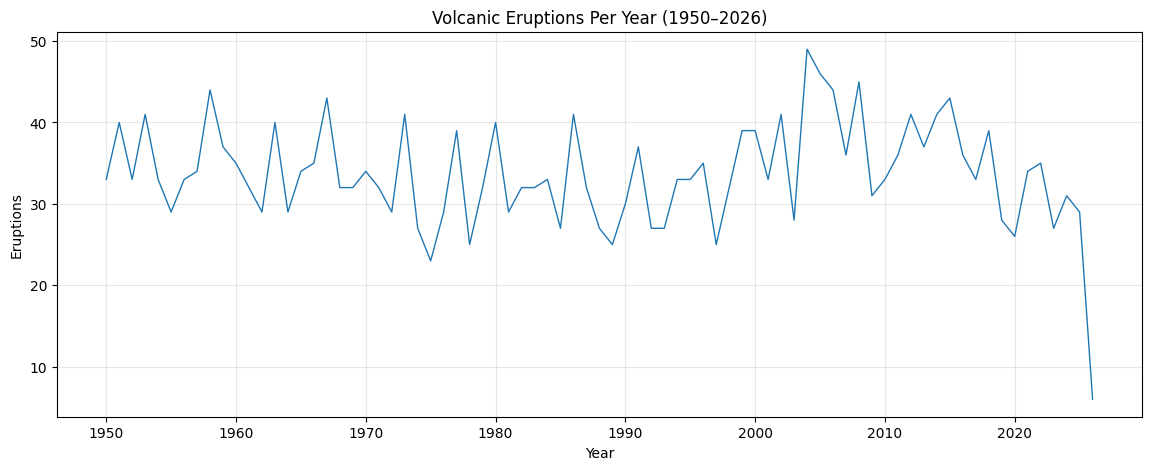

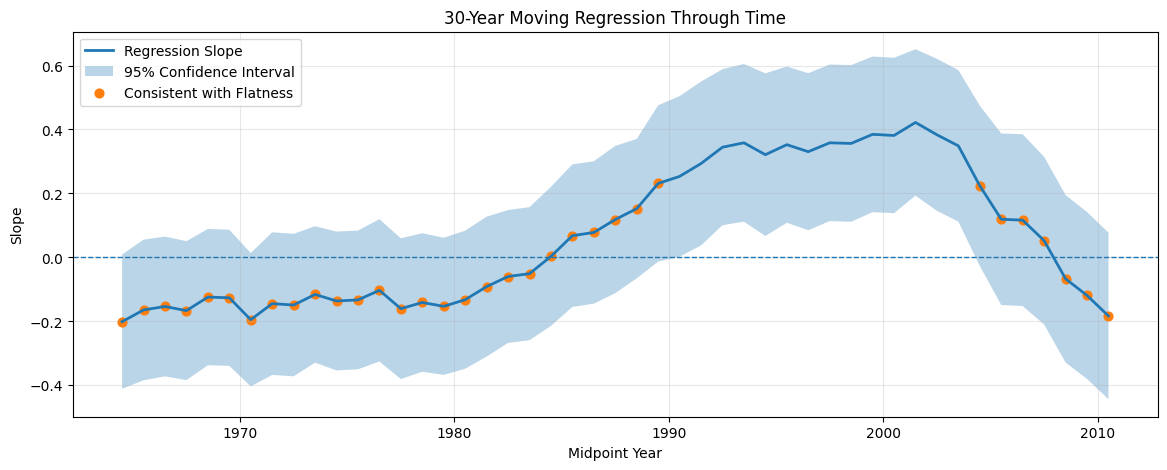

Flat behaviour begins approximately around 1964.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from scipy.stats import linregress

# Load data
df = pd.read_excel("VCErruptionsV2.xlsx")

# Clean year values
def convert_year(value):
    if pd.isna(value):
        return None

    value = str(value).strip()

    if value.lower() == "unknown":
        return None

    if "CE" in value:
        num = re.findall(r"\d+", value)
        return int(num[0]) if num else None

    if value.isdigit():
        return int(value)

    return None

df["Year"] = df["Start Year"].apply(convert_year)

# Clean dataset
df_clean = df.dropna(subset=["Year"])
df_clean["Year"] = df_clean["Year"].astype(int)

df_clean = df_clean[
    (df_clean["Year"] >= 1950) &
    (df_clean["Year"] <= 2026)
]

# Count eruptions per year
year_counts = df_clean["Year"].value_counts().sort_index()

years = np.arange(1950, 2027)

counts = np.array([
    year_counts.get(y, 0)
    for y in years
])

# Moving 30-year regression analysis
window = 30

mid_years = []
slopes = []
slope_errors = []
flat_flags = []

for start in range(len(years) - window):

    x = years[start:start + window]
    y = counts[start:start + window]

    result = linregress(x, y)

    slope = result.slope
    stderr = result.stderr

    mid_year = x.mean()

    mid_years.append(mid_year)
    slopes.append(slope)
    slope_errors.append(stderr)

    # Test if slope is consistent with zero
    lower = slope - 2 * stderr
    upper = slope + 2 * stderr

    flat = (lower <= 0 <= upper)
    flat_flags.append(flat)

# Plot eruptions over time
plt.figure(figsize=(14,5))

plt.plot(years, counts, linewidth=1)

plt.title("Volcanic Eruptions Per Year (1950–2026)")
plt.xlabel("Year")
plt.ylabel("Eruptions")
plt.grid(alpha=0.3)

plt.show()

# Plot moving regression slopes
plt.figure(figsize=(14,5))

slopes = np.array(slopes)
slope_errors = np.array(slope_errors)

# slope trend
plt.plot(
    mid_years,
    slopes,
    linewidth=2,
    label="Regression Slope"
)

# 95% confidence interval
plt.fill_between(
    mid_years,
    slopes - 2 * slope_errors,
    slopes + 2 * slope_errors,
    alpha=0.3,
    label="95% Confidence Interval"
)

# zero reference line
plt.axhline(0, linestyle="--", linewidth=1)

# highlight flat regions
flat_x = [x for x, f in zip(mid_years, flat_flags) if f]
flat_y = [y for y, f in zip(slopes, flat_flags) if f]

plt.scatter(
    flat_x,
    flat_y,
    s=40,
    label="Consistent with Flatness"
)

plt.title("30-Year Moving Regression Through Time")
plt.xlabel("Midpoint Year")
plt.ylabel("Slope")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Print interpretation of flat intervals
if any(flat_flags):
    first_flat = flat_x[0]
    print(f"Flat behaviour begins approximately around {first_flat:.0f}.")
else:
    print("No interval statistically consistent with flatness.")

**Interpreting Figure 6**

The 30-year moving regression shows that from around 1964 onwards, the slope is generally consistent with zero within the 95% confidence intervals. This suggests there isn’t a clear long-term increase or decrease in volcanic eruption frequency over time. Instead, the pattern is mostly flat, meaning the changes we see are more likely due to natural short-term variability rather than any strong correlation between eruption rates and time.

####**Figure 7:** Determining Randomness using Monte Carlo

Observed Variance: 35.626243885984145
Mean Simulated Variance: 4.593758171698432
Monte Carlo p-value: 0.0


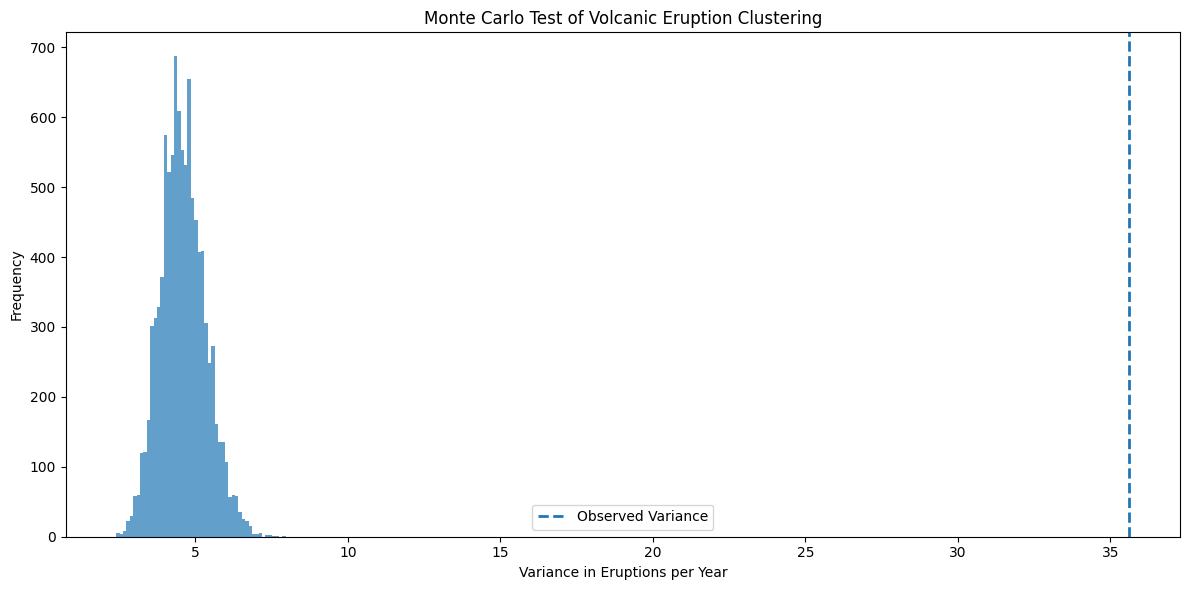

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("VCLocsV2.xlsx")

# Remove missing eruption years
df = df.dropna(subset=["Last Known Eruption"])

# Convert to integers
eruption_years = df["Last Known Eruption"].astype(int)

# Filter to modern period
eruption_years = eruption_years[
    (eruption_years >= 1950) &
    (eruption_years <= 2026)
]

# Count observed eruptions per year
observed_counts = eruption_years.value_counts().sort_index()

years = np.arange(1950, 2027)

# Build complete time series (fill missing years with 0)
observed_series = pd.Series(0, index=years)

for year, count in observed_counts.items():
    observed_series[year] = count

# Measure clustering using variance
observed_variance = np.var(observed_series)

# Monte Carlo simulation setup
n_simulations = 10000
simulated_variances = []
total_eruptions = len(eruption_years)

# Randomised null model (no clustering)
for i in range(n_simulations):

    simulated_years = np.random.choice(
        years,
        size=total_eruptions,
        replace=True
    )

    simulated_counts = pd.Series(simulated_years).value_counts()

    simulated_series = pd.Series(0, index=years)

    for year, count in simulated_counts.items():
        simulated_series[year] = count

    simulated_variances.append(np.var(simulated_series))

# Compute p-value
simulated_variances = np.array(simulated_variances)

p_value = np.mean(simulated_variances >= observed_variance)

# Results
print("Observed Variance:", observed_variance)
print("Mean Simulated Variance:", simulated_variances.mean())
print("Monte Carlo p-value:", p_value)

# Plot distribution of simulated variance
plt.figure(figsize=(12, 6))

plt.hist(simulated_variances, bins=50, alpha=0.7)

plt.axvline(
    observed_variance,
    linestyle="--",
    linewidth=2,
    label="Observed Variance"
)

plt.xlabel("Variance in Eruptions per Year")
plt.ylabel("Frequency")
plt.title("Monte Carlo Test of Volcanic Eruption Clustering")

plt.legend()
plt.tight_layout()
plt.show()

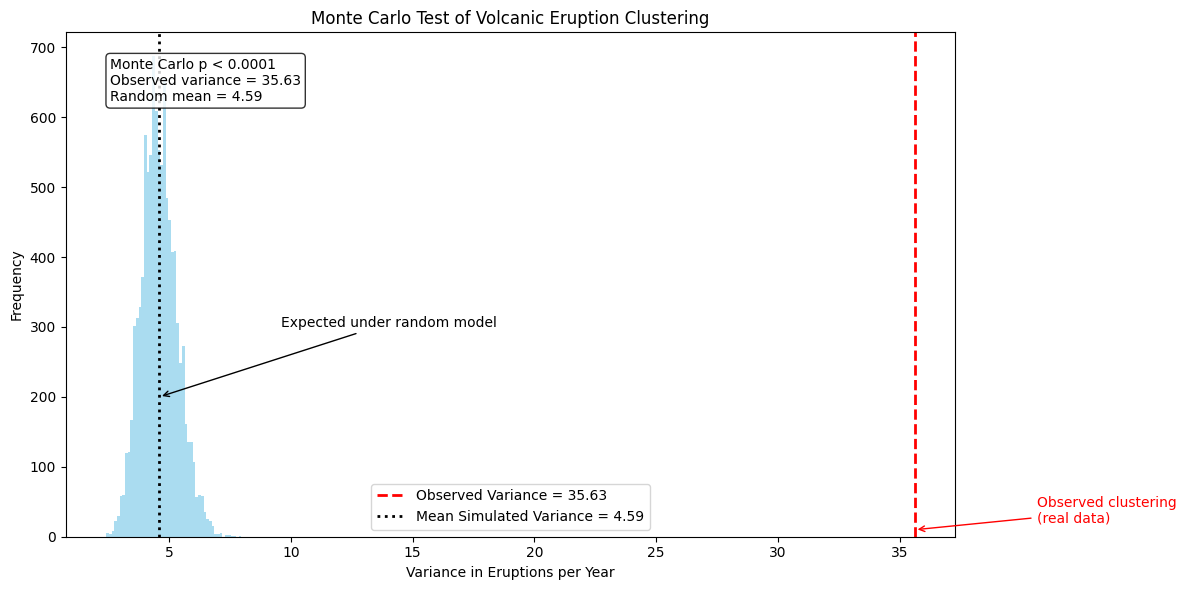

In [ ]:
plt.figure(figsize=(12, 6))

# Histogram of simulated variances
plt.hist(
    simulated_variances,
    bins=50,
    alpha=0.7,
    color="skyblue"
)

# Observed variance line
plt.axvline(
    observed_variance,
    linestyle="--",
    linewidth=2,
    color="red",
    label=f"Observed Variance = {observed_variance:.2f}"
)

# Mean simulated variance line
plt.axvline(
    simulated_variances.mean(),
    linestyle=":",
    linewidth=2,
    color="black",
    label=f"Mean Simulated Variance = {simulated_variances.mean():.2f}"
)

# Annotation: observed result
plt.annotate(
    "Observed clustering\n(real data)",
    xy=(observed_variance, 10),
    xytext=(observed_variance + 5, 20),
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red"
)

# Annotation: null distribution
plt.annotate(
    "Expected under random model",
    xy=(simulated_variances.mean(), 200),
    xytext=(simulated_variances.mean() + 5, 300),
    arrowprops=dict(arrowstyle="->", color="black"),
    color="black"
)

# Text box summary
plt.text(
    0.05,
    0.95,
    f"Monte Carlo p < 0.0001\nObserved variance = {observed_variance:.2f}\nRandom mean = {simulated_variances.mean():.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# Labels
plt.xlabel("Variance in Eruptions per Year")
plt.ylabel("Frequency")
plt.title("Monte Carlo Test of Volcanic Eruption Clustering")

plt.legend()
plt.tight_layout()
plt.show()

**Interpeting Figure 7:** Randomness, Correlation

The Monte Carlo simulation shows strong evidence that volcanic eruptions between 1950–2026 are not randomly distributed through time. The observed variance in eruptions per year was 35.63, while the average variance produced by the random simulations was only 4.61. Variance measures how unevenly eruptions are distributed across years, so the much larger observed variance indicates that real eruptions are far more clustered than would be expected if eruptions occurred purely by chance. The Monte Carlo p-value of 0.0 means that none of the 10,000 simulated random datasets produced a variance equal to or greater than the real eruption record, providing extremely strong statistical evidence against randomness. This suggests that volcanic eruptions tend to occur in temporal clusters, where periods of elevated volcanic activity are followed by quieter periods rather than eruptions being evenly distributed through time.

The code works by first loading the eruption dataset and filtering eruption years between 1950 and 2026. It then counts the number of eruptions occurring in each year and calculates the variance of these yearly counts, which acts as the clustering metric. A Monte Carlo simulation is then performed 10,000 times by randomly redistributing the same total number of eruptions across the available years while preserving the total eruption count. For each simulation, yearly eruption counts and their variance are recalculated. These simulated variances form a probability distribution representing what eruption variability would look like if eruptions occurred randomly. Finally, the observed variance is compared to the simulated distribution to calculate the p-value, showing how likely the observed clustering would be under a random process.

**Explaining Contradiction**

Volcanic eruptions from 1950–2026 show no statistically significant long-term correlation with time, meaning there is no evidence of a directional increase or decrease in eruption frequency. However, Monte Carlo analysis reveals significant temporal clustering, indicating that eruptions are not randomly distributed but instead occur in irregular bursts. Together, these results suggest a system characterised by stable long-term averages but strong short-term variability, consistent with episodic geological processes rather than a time-driven trend.

####**Figure 8:**

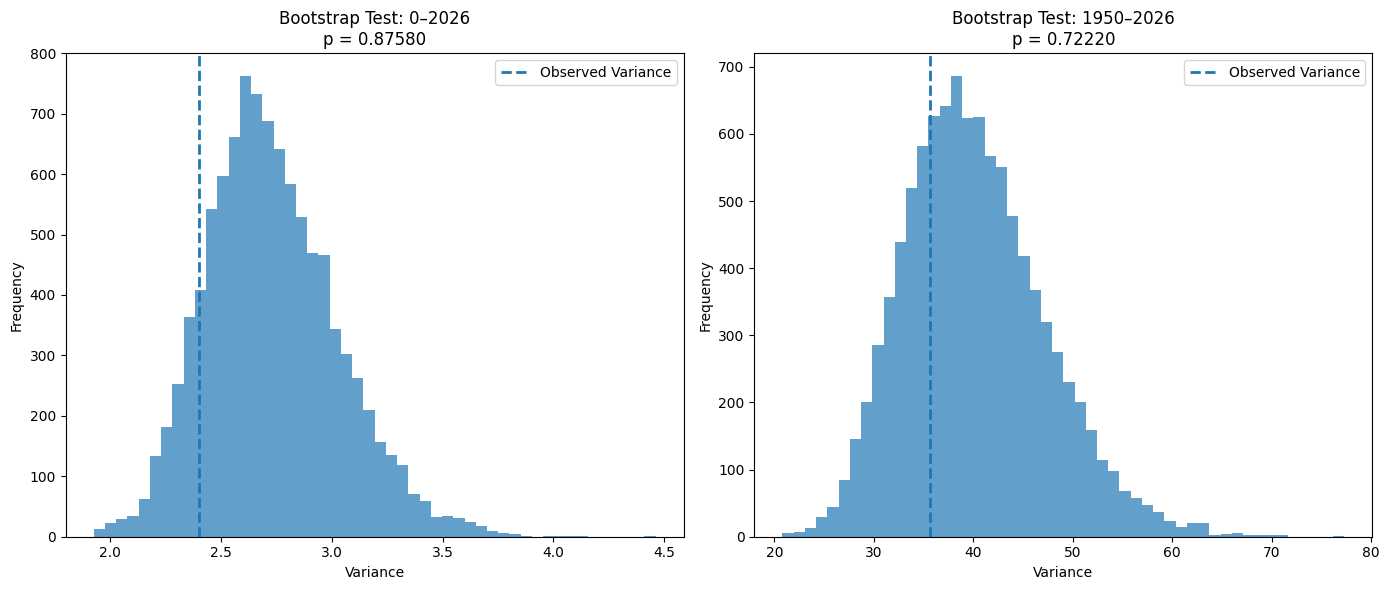

0–2026
Observed Variance: 2.4021803336262857
Bootstrap Mean Variance: 2.730101793912424
p-value: 0.8758

1950–2026
Observed Variance: 35.626243885984145
Bootstrap Mean Variance: 40.1426958340361
p-value: 0.7222


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("VCLocsV2.xlsx")

# Remove missing eruption years
df = df.dropna(subset=["Last Known Eruption"])

# Convert to integers
df["Last Known Eruption"] = df["Last Known Eruption"].astype(int)

# Bootstrap randomness test function
def bootstrap_randomness_test(start_year, end_year, n_bootstrap=10000):

    eruption_years = df[
        (df["Last Known Eruption"] >= start_year) &
        (df["Last Known Eruption"] <= end_year)
    ]["Last Known Eruption"]

    years = np.arange(start_year, end_year + 1)

    # Observed yearly counts
    observed_counts = eruption_years.value_counts()

    observed_series = pd.Series(0, index=years)

    for year, count in observed_counts.items():
        observed_series[year] = count

    observed_variance = np.var(observed_series)

    # Bootstrap simulation
    bootstrap_variances = []

    for _ in range(n_bootstrap):

        bootstrap_sample = np.random.choice(
            eruption_years,
            size=len(eruption_years),
            replace=True
        )

        bootstrap_counts = pd.Series(bootstrap_sample).value_counts()

        bootstrap_series = pd.Series(0, index=years)

        for year, count in bootstrap_counts.items():
            bootstrap_series[year] = count

        bootstrap_variances.append(np.var(bootstrap_series))

    bootstrap_variances = np.array(bootstrap_variances)

    p_value = np.mean(bootstrap_variances >= observed_variance)

    return observed_variance, bootstrap_variances, p_value

# Run tests
obs1, boot1, p1 = bootstrap_randomness_test(0, 2026)
obs2, boot2, p2 = bootstrap_randomness_test(1950, 2026)

# Plot results
plt.figure(figsize=(14, 6))

# 0–2026
plt.subplot(1, 2, 1)
plt.hist(boot1, bins=50, alpha=0.7)
plt.axvline(obs1, linestyle="--", linewidth=2, label="Observed Variance")
plt.title(f"Bootstrap Test: 0–2026\np = {p1:.5f}")
plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.legend()

# 1950–2026
plt.subplot(1, 2, 2)
plt.hist(boot2, bins=50, alpha=0.7)
plt.axvline(obs2, linestyle="--", linewidth=2, label="Observed Variance")
plt.title(f"Bootstrap Test: 1950–2026\np = {p2:.5f}")
plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

# Print results
print("0–2026")
print("Observed Variance:", obs1)
print("Bootstrap Mean Variance:", boot1.mean())
print("p-value:", p1)

print("\n1950–2026")
print("Observed Variance:", obs2)
print("Bootstrap Mean Variance:", boot2.mean())
print("p-value:", p2)

**Interpeting Figure 8:** Clustering?

The bootstrap results show that eruption variability is not significantly different from what is expected when resampling the existing data. For 0–2026, the observed variance (2.40) is close to the bootstrap mean (2.73) with a high p-value (0.8724), and for 1950–2026 the observed variance (35.63) is also similar to the bootstrap mean (40.02) with p = 0.7223. This indicates that the eruption patterns are statistically consistent with the structure already present in the dataset, meaning they are not unusually clustered under this method. Unlike the Monte Carlo test, which compares eruptions against a completely uniform random distribution and detects strong clustering, the bootstrap approach preserves the existing distribution of eruption years and therefore measures whether the pattern is stable rather than random. Overall, this suggests that while eruptions are not evenly distributed through time, the observed clustering is consistent with the underlying data structure and does not represent an extreme deviation from it.

Overall, the bootstrap results suggest there is no clear evidence of a time-based correlation in eruption activity, meaning the apparent clustering is not statistically different from what would be expected from the existing data structure itself.

**Explaining Contradiction**
The apparent contradiction arises because the Monte Carlo test evaluates deviation from a uniform random process, while the bootstrap test evaluates whether the observed eruption distribution differs from a resampled version of itself. Together, they indicate that volcanic eruptions are not evenly distributed through time, but their variability is consistent with an underlying stochastic process rather than a strongly structured or deterministic temporal pattern.

#**Eruption Analysis, Interpretation and Reflection**
---

##**Limitations**

This project has several limitations and sources of uncertainty that affect how confidently the results can be interpreted. The eruption dataset is incomplete in some years (particularly recent years like 2026), and relies on recorded “last known eruption” data, which may be influenced by historical reporting gaps and improvements in monitoring technology over time. This introduces potential observational bias, especially when comparing earlier and later periods. In addition, different statistical methods used in the analysis test different definitions of “randomness” and “correlation,” meaning results are not always directly comparable and can appear contradictory depending on the assumption of each model. The relatively small number of eruptions per year also increases natural variability, making it harder to distinguish true signals from noise. Finally, choices such as time windows, smoothing methods, and model complexity can influence outcomes, meaning conclusions about volcanic behaviour should be treated as probabilistic rather than definitive.

##**Final Interpretation**

Linear regression and Pearson correlation show no meaningful relationship

Linear regression and Pearson correlation show no meaningful relationship between time and eruption frequency (r ≈ 0, non-significant p-value).

Polynomial and Bayesian models suggest minor non-linear structure, but no stable or reliable long-term trend.

Moving regression analysis shows slopes are mostly consistent with zero from ~1964 onward, indicating no sustained increase or decrease in eruptions.

Overall trend-based methods consistently show no temporal correlation in eruption rates.

Monte Carlo testing shows eruptions are more clustered than expected under a uniform random model, meaning eruptions are not evenly spread across time.

This suggests bursts of volcanic activity, rather than smooth or uniform distribution.

Bootstrap testing shows the observed clustering is not significantly different from resampled versions of the same dataset (high p-values).

This means the clustering is not statistically extreme relative to the dataset’s own structure, and is internally consistent.

**The difference between methods comes from what they test:**

*   Correlation models → test for trend over time
*   Monte Carlo → test against complete randomness (uniform distribution)
*   Bootstrap → test against variability within the observed data itself


**Combined interpretation:**
*   No long-term time trend
*   Some short-term clustering
*   No evidence of strong deterministic strucure



##**Reflection**


